# Libraries

In [22]:
import pandas as pd
import networkx as nx
import numpy as np
import osmnx as ox
import geopandas as gpd
import pickle
from tqdm import tqdm
import os
import re
import rasterio as rs
import random
import matplotlib.pyplot as plt
from haversine import haversine, Unit

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set home directory
home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Research/Global road network resilience/01_data' # CURA
home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology(2)/Research/Global road network resilience/01_data' # SCARP
home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Research/Global road network resilience/01_data' # Home

# Validation

## Road segment height

In this project, we extract the 

### Step 1: Sample 5 networks for each World Bank region (7 regions, 35 networks worldwide)

In [ ]:
# Read settlement cluster shapefiles
clusters_2564_dir = "/final_bnd/poly_2564_WB_regions.shp"
clusters_2564 = gpd.read_file(home_dir + clusters_2564_dir)

# Number of random network IDs to select per World Bank region
n_samples = 5

# Group by 'REGION_WB' and sample 'n_samples' random rows from each group
# The result will be a new DataFrame containing the sampled rows.
random_network_ids_per_region = clusters_2564.groupby('REGION_WB').sample(n=n_samples, random_state=2025)

# Save sampled network ids in csv file
random_network_ids_per_region.to_csv(home_dir+"/road_elevation_validation/sampled_35networks.csv")

In [66]:
# Print only the net_id and region
print("\nSampled 'net_id' for each region:")
print(random_network_ids_per_region[['REGION_WB', 'net_id']])


Sampled 'net_id' for each region:
                       REGION_WB  net_id
599          East Asia & Pacific  1679.0
1338         East Asia & Pacific  2849.0
1545         East Asia & Pacific  3225.0
2160         East Asia & Pacific  4215.0
1444         East Asia & Pacific  3021.0
2598       Europe & Central Asia   847.0
121        Europe & Central Asia  1143.0
1668       Europe & Central Asia   343.0
1805       Europe & Central Asia   368.0
1346       Europe & Central Asia   287.0
1639   Latin America & Caribbean  3366.0
894    Latin America & Caribbean  2002.0
1615   Latin America & Caribbean  3328.0
1965   Latin America & Caribbean  3962.0
2070   Latin America & Caribbean  4103.0
929   Middle East & North Africa  2062.0
452   Middle East & North Africa  1521.0
833   Middle East & North Africa  1926.0
1161  Middle East & North Africa  2550.0
932   Middle East & North Africa  2066.0
686                North America  1753.0
394                North America  1456.0
174                Nor

### Step 2: Extract OSM road networks

In [ ]:
# CSV file with sampled network IDs
random_network_ids_per_region = pd.read_csv(home_dir+"/road_elevation_validation/sampled_35networks.csv", index_col=0)

# Define coordinate reference system: WGS84 - World Geodetic System 1984 used in GPS
crs_lonlat = {'init': 'epsg:' + str(4326)}

# Read in the shapefile with the convex hulls of the settlement cluster boundaries
convex_hull_2564_shp = gpd.read_file(home_dir + '/final_bnd/poly_2564_WB_regions.shp').to_crs(crs_lonlat)

# Loop through the sampled network ids and extract OSM road networks
for net_id in random_network_ids_per_region.net_id.values:
    # Select convexhull poly
    convex_hull_sel = convex_hull_2564_shp[convex_hull_2564_shp["net_id"] == net_id].iloc[0]
    G = ox.graph_from_polygon(convex_hull_sel.geometry, network_type='drive_service')
    with open(home_dir + '/road_elevation_validation/sampled_networks/g_raw_drive_conv_' + str(net_id) + '.pk', 'wb') as handle:
        pickle.dump(G, handle, protocol=2)

OPTIONAL: examine road types in raw OSM networks

In [197]:
# [OPTIONAL] This cell examines the highway classes or road types
# Initiate dataframe to store road types
net_type_df = pd.DataFrame(columns=['net_id', 'net_types'], index=range(35))
counter = 0
net_type_lst = [] # Initiate list of network types

# Examine the road types
# Function to remove list nestings in highway road classes
def removeNestings(l): 
    output = []
    for i in l: 
        if type(i) == list: 
            output.extend(removeNestings(i))  # Use extend to add flattened results
        else: 
            output.append(i)
    return output

for file in os.listdir(home_dir + '/road_elevation_validation/sampled_networks/'):
    if file.endswith('.pk'):
        G = pickle.load(open(home_dir + '/road_elevation_validation/sampled_networks/' + file, 'rb'))
        net_id = int(file.split("_")[-1].split(".")[0])
        net_type_df.at[counter, 'net_id'] = net_id
        # Highway class unique values
        highway_class_dict = nx.get_edge_attributes(G,'highway')
        highway_class_lst = []
        for item in highway_class_dict.values():
            highway_class_lst.append(item)
        net_type_df.at[counter, 'net_types'] = list(set(removeNestings(highway_class_lst)))
        counter += 1
        net_type_lst.append(list(set(removeNestings(highway_class_lst))))

Below a dataframe of network id and unique road network types is created.

In [201]:
net_type_df.head(5)

,net_id,net_types
0,1521,"[tertiary, living_street, tertiary_link, resid..."
1,2550,"[tertiary, tertiary_link, residential, trunk_l..."
2,287,"[tertiary, living_street, tertiary_link, resid..."
3,3910,"[tertiary, living_street, residential, trunk_l..."
4,3481,"[tertiary, living_street, tertiary_link, resid..."


These are the unique road network types for all 35 sampled networks

In [207]:
set(removeNestings(net_type_lst))

{'yes', 'trunk_link', 'secondary_link', 'escape', 'step', 'tertiary_link', 'trunk', 'bus_stop', 'residential', 'motorway_link', 'primary_link', 'road', 'tertiary', 'living_street', 'service', 'crossing', 'unclassified', 'motorway', 'secondary', 'primary', 'busway'}

Remove highway classes that cause data bias

In [229]:
# Identify highway classes to remove
highway_classes_to_remove = [
    'yes',
    'escape',
    'step',
    'tertiary_link',
    'bus_stop',
    'residential',
    'tertiary',
    'living_street',
    'service',
    'crossing',
    'unclassified',
    'busway'
                             ]
for file in os.listdir(home_dir + '/road_elevation_validation/sampled_networks/'):
    if file.endswith('.pk'):
        net_id = int(file.split('_')[-1].split('.')[0])
        G = pickle.load(open(home_dir + '/road_elevation_validation/sampled_networks/' + file, 'rb'))
        G_lite = G.copy()
        for i,j,data in G.edges.data():
            highway_cls = data['highway']
            if highway_cls in highway_classes_to_remove:
                G_lite.remove_edge(i, j)
        # Remove isolated nodes as a result of the edge removal
        G_lite.remove_nodes_from(list(nx.isolates(G_lite)))
        with open(home_dir + '/road_elevation_validation/sampled_networks_lite/graph_cov_lite_' + str(int(net_id)) + '.pk', 'wb') as handle:
                pickle.dump(G_lite, handle, protocol=2)


### Step 3: Attach elevation values to road network

In [ ]:
# Extract road elevation using Google API
for file in os.listdir(home_dir + '/road_elevation_validation/sampled_networks_lite/'):
    if file.endswith('.pk'):
        net_id = int(file.split('_')[-1].split('.')[0])
        G = pickle.load(open(home_dir + '/road_elevation_validation/sampled_networks_lite/' + file, 'rb'))
        # add elevation to each of the nodes, using the google elevation API, then calculate edge grades
        G = ox.elevation.add_node_elevations_google(G, api_key='your API key here')
        G = ox.add_edge_grades(G)
        # Save as graphml
        ox.io.save_graphml(G, home_dir + f'/road_elevation_validation/sampled_network_lite_elev_graphml/graph_cov_lite_elev_{net_id}.graphml')
        # Save as geopackage
        ox.io.save_graph_geopackage(G, home_dir + f"/road_elevation_validation/sampled_network_lite_elev_gpkg/graph_cov_lite_elev_{net_id}.gpkg")

## **Houston**: Empirical validation with observed road closures from Hurricane Harvey

In [3]:
houston_graph_10flood = pickle.load(open(home_dir + '/Harvey_validation/G_cov_no_r_2139_10flooded.pk', 'rb'))

/var/folders/nc/ywj4rgkn46l95_tqft45f5640000gs/T/ipykernel_19125/4091128666.py:1: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  houston_graph_10flood = pickle.load(open(home_dir + '/Harvey_validation/G_cov_no_r_2139_10flooded.pk', 'rb'))


In [ ]:
# Critical inundation thresholds
gamma_lst = [0.3, 0.25, 0.2, 0.15]

# Flood return period
rp = 1000

for gamma in gamma_lst:
    # Make a copy of the graph with flood inundation values
    houston_disrupted_graph = houston_graph_10flood.copy()
    # Delete nodes with flood inundation greater than 30mm or 0.3m
    for node_id, node_data in houston_graph_10flood.nodes.data():
        if node_data['FUP_' + str(rp)] >= gamma:
            houston_disrupted_graph.remove_node(node_id)
    # Delete edges with flood inundation greater than 30mm or 0.3m
    houston_disrupted_graph2 = houston_disrupted_graph.copy()
    for start_id, end_id, edge_data in houston_disrupted_graph.edges.data():
        try:
            if edge_data['FUP_' + str(rp)] >= gamma:
                houston_disrupted_graph2.remove_edge(start_id, end_id)
        except KeyError:
            continue

## **Nanjing**: Empirical validation with observed travel time changes during flood events

### Step 1: Build network model

In [8]:
# Define coordinate reference system: WGS84 - World Geodetic System 1984 used in GPS
crs_lonlat = {'init': 'epsg:' + str(4326)}

# Read in the shapefile with the convex hulls of the settlement cluster boundaries
nanjing_bnd_shp = gpd.read_file(home_dir + '/01_public/Nanjing_validation/Nanjing_city_bnd.shp').to_crs(crs_lonlat)

# Extract OSM road network for Nanjing City
poly = nanjing_bnd_shp.geometry.iloc[0]
G = ox.graph_from_polygon(poly, network_type='drive_service')
with open(home_dir + '/01_public/Nanjing_validation/nj_raw_drive.pk', 'wb') as handle:
    pickle.dump(G, handle, protocol=2)

/opt/miniconda3/envs/global0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [ ]:
# Function to remove list nestings in highway road classes
def removeNestings(l): 
    output = []
    for i in l: 
        if type(i) == list: 
            output.extend(removeNestings(i))  # Use extend to add flattened results
        else: 
            output.append(i)
    return output

# Highway class unique values
highway_class_dict = nx.get_edge_attributes(G,'highway')
highway_class_lst = []
for item in highway_class_dict.values():
    highway_class_lst.append(item)

# Identify highway classes to remove
highway_classes_to_remove = [
    'tertiary_link',
    'road',
    'residential',
    'tertiary',
    'living_street',
    'service',
    'unclassified'
                             ]

# Delete 'highway' classes that are not included in the scope of study
G_lite = G.copy()
for i,j,data in G.edges.data():
    highway_cls = data['highway']
    if highway_cls in highway_classes_to_remove:
        G_lite.remove_edge(i, j)
    # Remove isolated nodes as a result of the edge removal
    G_lite.remove_nodes_from(list(nx.isolates(G_lite)))
    # Save resulting graph as pickle file
    with open(home_dir + '/01_public/Nanjing_validation/nj_lite.pk', 'wb') as handle:
        pickle.dump(G_lite, handle, protocol=2)

# Save as geopackage
ox.io.save_graph_geopackage(G_lite, home_dir + '/01_public/Nanjing_validation/nj_lite.gpkg')

# add elevation to each of the nodes, using the google elevation API, then calculate edge grades
G_lite = ox.elevation.add_node_elevations_google(G_lite, api_key='your api key here')
G_lite = ox.add_edge_grades(G_lite)

# Save as graphml
ox.io.save_graphml(G_lite, home_dir + '/01_public/Nanjing_validation/nj_lite_elev.graphml')
# Save as geopackage
ox.io.save_graph_geopackage(G_lite, home_dir + "/01_public/Nanjing_validation/nj_lite_elev.gpkg")

### Step 2: Dry condition routing

In [132]:
# Load network/graph with edge speed and travel time
nj_graph = pickle.load(open(home_dir + '/Nanjing_validation/G_nj_flooded_speed_time.pk', 'rb'))

In [171]:
# dry simulation
# Load node probability
node_pop_prob = pd.read_csv(home_dir + '/Nanjing_validation/nj_pop_probability.csv', index_col=0)
# Only keep nodes that is matches the ones in the graph
nj_graph_node_lst = list(map(int, list(nj_graph.nodes())))
node_pop_prob_filtered = node_pop_prob[node_pop_prob['osmid'].isin(nj_graph_node_lst)]

# List of node osmnid and corresponding sample probability
node_osmid_lst = list(map(int, node_pop_prob_filtered.osmid.values))
node_prob_lst = list(node_pop_prob_filtered.p_1.values)

OD_df = pd.DataFrame(columns=[  'index',
                                'O_node_id',
                                'D_node_id',
                                'OD_route',
                                'OD_route_time_s'])

epsilon = float('inf')
travel_time_lst = []
index = 0

while epsilon > 0.01:
    # Sample origin
    sample_O_pt = random.choices(node_osmid_lst, node_prob_lst)[0]
    sample_D_pt = random.choices(node_osmid_lst, node_prob_lst)[0]
    while sample_O_pt == sample_D_pt:
            sample_D_pt = random.choices(node_osmid_lst, node_prob_lst)[0]

    #
    try:
        OD_route = nx.shortest_path(nj_graph, str(sample_O_pt), str(sample_D_pt), weight='travel_time') # route
        OD_route_time = nx.shortest_path_length(nj_graph, str(sample_O_pt), str(sample_D_pt), weight='travel_time') # seconds
        travel_time_lst.append(OD_route_time)
    
        OD_df.loc[index] = [index+1, sample_O_pt, sample_D_pt, OD_route, OD_route_time]

        if len(travel_time_lst) == 1:
                epsilon = float('inf')
        else:
                epsilon = abs(np.mean(travel_time_lst) - np.mean(travel_time_lst[:-1]))

        index += 1
    except nx.NetworkXNoPath:
        continue

OD_df.to_csv(home_dir + '/Nanjing_validation/nj_OD_df.csv')

### Step 3: Wet condition routing

##### 3.1 Generate disrupted graphs under 10 return periods and 4 inundation thresholds (gamma = 0.3, 0.25, 0.2, 0.15, unit:meters)

In [ ]:
# Load network/graph with edge speed and travel time
nj_graph = pickle.load(open(home_dir + '/Nanjing_validation/G_nj_flooded_speed_time.pk', 'rb'))
flooded_graphs_dir = home_dir + '/Nanjing_validation/flooded_graphs' # folder to store disrupted graphs

gamma_lst = [0.3, 0.25, 0.2, 0.15]

RP_lst = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]


for rp in RP_lst:
    print('I am working on RP=' + str(rp))
    for gamma in gamma_lst:
        # Make a copy of the graph
        nj_graph_copy = nj_graph.copy()
        # Delete nodes with flood inundation greater than 30cm or 0.3m
        for node_id, node_data in nj_graph.nodes.data():
            if node_data['FUP_max_rp' + str(rp)] >= gamma and node_data['FUP_max_rp' + str(rp)] < 99:
                nj_graph_copy.remove_node(node_id)

        # Add flood travel speed
        for start_id, end_id, edge_data in nj_graph_copy.edges.data():
            edge_water_depth_m = max(nj_graph_copy.nodes[start_id]['FUP_max_rp'+str(rp)], nj_graph_copy.nodes[end_id]['FUP_max_rp'+str(rp)])
            edge_flood_depth_mm = edge_data['FUP_max_rp'+str(rp)]*1000 # unit:mm
            designed_speed_ms = edge_data['ms'] # m/s
            theoretical_speed_ms = (86.9448 - (0.5529*edge_flood_depth_mm) + (0.0009*edge_flood_depth_mm*edge_flood_depth_mm))/3.6 # m/s
            speed_final = min(theoretical_speed_ms, designed_speed_ms)
            nj_graph_copy[start_id][end_id][0]['speed_ms_rp'+ str(rp) + "_" + str(gamma)] = speed_final
            nj_graph_copy[start_id][end_id][0]['time_s_rp'+ str(rp) + "_" + str(gamma)] = float(edge_data['length'])/speed_final

        with open(flooded_graphs_dir + '/nj_graph_disrupted_FUP_' + str(rp) + "_" + str(gamma)+ '.pk', 'wb') as handle:
            pickle.dump(nj_graph_copy, handle, protocol=2)

I am working on RP=5
I am working on RP=10
I am working on RP=20
I am working on RP=50
I am working on RP=75
I am working on RP=100
I am working on RP=200
I am working on RP=250
I am working on RP=500
I am working on RP=1000


##### 3.2 OD simulation in flooded graphs

In [ ]:
# Gamma = 0.3 meters
gamma = 0.3

# Load OD pairs from dry routing
OD_baseline = pd.read_csv(home_dir + '/Nanjing_validation/nj_OD_df.csv', index_col=0)

wet_OD_df = OD_baseline.copy()
# Load disrupted graph
RP_lst = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
for rp in RP_lst:
    # Initiate column to store new route
    wet_OD_df[f'OD_route_FUP_{rp}_{gamma}'] = None
    wet_OD_df[f'OD_time_s_FUP_{rp}_{gamma}'] = 0

    # Load disrupted graph
    nj_graph = pickle.load(open(home_dir + '/Nanjing_validation/flooded_graphs' + '/nj_graph_disrupted_FUP_' + str(rp) + "_" + str(gamma)+ '.pk', 'rb'))

    # Run travel simulation between OD pairs
    for row_idx in range(wet_OD_df.shape[0]):
        O_node_id = wet_OD_df.iloc[row_idx]['O_node_id']
        D_node_id = wet_OD_df.iloc[row_idx]['D_node_id']

        try:
            wet_OD_route = nx.shortest_path(nj_graph, str(O_node_id), str(D_node_id), weight=f'time_s_rp{rp}_{gamma}') # route
            wet_OD_route_time = nx.shortest_path_length(nj_graph, str(O_node_id), str(D_node_id), weight=f'time_s_rp{rp}_{gamma}') # seconds

            wet_OD_df.at[row_idx, f'OD_route_FUP_{rp}_{gamma}'] = wet_OD_route
            wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
        except:
            continue
wet_OD_df.to_csv(home_dir + f'/Nanjing_validation/nj_OD_df_flood10_{gamma}.csv')

/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/106330981.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1977.853143606548' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/106330981.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4479.487982746327' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/106330981.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6486.482

### Step 4: AMAP data processing

In [ ]:
"""process AMAP travel dataset"""

# 20240711 flooding
ds,o_adcode,d_adcode,source_grid,target_grid,str_time,end_time,vehicle_type,vehicle_size,energy_type,o_xy,d_xy,cnt = [], [], [], [], [], [], [], [], [], [], [], [], []
path = home_dir + '/Nanjing_validation/Nanjing_WPW/Real Data/20240711.txt'
with open(path) as f:
    print(f.readline())
    k = 0
    while f.readable():
        if k % 1000000 == 0:
            print("Begin to deal with the ", k, "th row...")
        datas = f.readline().strip("\n").split(",")
        if len(datas) == 1:  # if row empty then it is the last row of the dataset; 若数据为空行，则代表已经到达尾行
            break
        ds.append(datas[0])    # Datetime, format: YYYYMMDD; 日期，格式为YYYYMMDD，如20230301
        o_adcode.append(datas[1])    # Origin code; 起点城市代码(区县级)
        d_adcode.append(datas[2])    # Destination code; 终点城市代码(区县级)
        source_grid.append(datas[3])    # Network ID for origin; 起点网格ID（100 米）
        target_grid.append(datas[4])    # Network ID for destination; 终点网格ID（100 米）
        str_time.append(datas[5])   # Trip start time; 开始时间，间隔为15 分钟，可能为空   1215 表示 12:15
        end_time.append(datas[6])   # Trip end time; 结束时间，间隔为15 分钟，可能为空
        vehicle_type.append(datas[7])   # Vehicle type: 1 Truck, 0 Private car; 汽车类型，1 是货车，0 是汽车
        vehicle_size.append(datas[8])   # Vehicle model; 汽车型号，重型货车、中型货车、小型货车等
        energy_type.append(datas[9])   # Whether is electric vehicle, 1 yes, 0 no; 是否为电车，1 为电车，0 为油车
        o_xy.append(datas[10])   # Lat and lon of origin; 起点网格中心点经纬度(GCJ-02 坐标系)
        d_xy.append(datas[11])   # Lat and lon of destination; 终点网格中心点经纬度(GCJ-02 坐标系)
        cnt.append(datas[12])   # Count; 数量

        k += 1

# 20240718 baseline
path = home_dir + '/Nanjing_validation/Nanjing_WPW/Real Data/20240718.txt'
with open(path) as f:
    print(f.readline())
    k = 0
    while f.readable():
        if k % 1000000 == 0:
            print("Begin to deal with the ", k, "th row...")
        datas = f.readline().strip("\n").split(",")
        if len(datas) == 1:  # if row empty then it is the last row of the dataset; 若数据为空行，则代表已经到达尾行
            break
        ds.append(datas[0])    # Datetime, format: YYYYMMDD; 日期，格式为YYYYMMDD，如20230301
        o_adcode.append(datas[1])    # Origin code; 起点城市代码(区县级)
        d_adcode.append(datas[2])    # Destination code; 终点城市代码(区县级)
        source_grid.append(datas[3])    # Network ID for origin; 起点网格ID（100 米）
        target_grid.append(datas[4])    # Network ID for destination; 终点网格ID（100 米）
        str_time.append(datas[5])   # Trip start time; 开始时间，间隔为15 分钟，可能为空
        end_time.append(datas[6])   # Trip end time; 结束时间，间隔为15 分钟，可能为空
        vehicle_type.append(datas[7])   # Vehicle type: 1 Truck, 0 Private car; 汽车类型，1 是货车，0 是汽车
        vehicle_size.append(datas[8])   # Vehicle model; 汽车型号，重型货车、中型货车、小型货车等
        energy_type.append(datas[9])   # Whether is electric vehicle, 1 yes, 0 no; 是否为电车，1 为电车，0 为油车
        o_xy.append(datas[10])   # Lat and lon of origin; 点网格中心点经纬度(GCJ-02 坐标系)
        d_xy.append(datas[11])   # Lat and lon of destination; 终点网格中心点经纬度(GCJ-02 坐标系)
        cnt.append(datas[12])   # Count; 数量

        k += 1

""" create dataframe"""
od_df_amap = pd.DataFrame()
od_df_amap['ds'] = ds
od_df_amap['o_adcode'] = o_adcode
od_df_amap['d_adcode'] = d_adcode
od_df_amap['source_grid'] = source_grid
od_df_amap['target_grid'] = target_grid 
od_df_amap['str_time'] = str_time
od_df_amap['end_time'] = end_time
od_df_amap['vehicle_type'] = vehicle_type
od_df_amap['vehicle_size'] = vehicle_size
od_df_amap['energy_type'] = energy_type
od_df_amap['o_xy'] = o_xy
od_df_amap['d_xy'] = d_xy
od_df_amap['cnt'] = pd.to_numeric(cnt)


""" duration calculation """
od_df_amap['str_time'] = od_df_amap['str_time'].apply(lambda x: int(x[:-2]) * 60 + int(x[-2:]))  # unit: minutes
od_df_amap['end_time'] = od_df_amap['end_time'].apply(lambda x: int(x[:-2]) * 60 + int(x[-2:]))  # unit: minutes
od_df_amap['dur_time'] = od_df_amap['end_time'] - od_df_amap['str_time'] # unit: minutes

""" distance calculation """
# extract the lat and lon values of origin and destination
od_df_amap['ox'] = pd.to_numeric(od_df_amap['o_xy'].apply(lambda row: row.split('_')[0]))   # CJ-02
od_df_amap['oy'] = pd.to_numeric(od_df_amap['o_xy'].apply(lambda row: row.split('_')[1]))
od_df_amap['dx'] = pd.to_numeric(od_df_amap['d_xy'].apply(lambda row: row.split('_')[0]))   # CJ-02
od_df_amap['dy'] = pd.to_numeric(od_df_amap['d_xy'].apply(lambda row: row.split('_')[1]))
# calculate haversine distance
od_df_amap['rad'] = od_df_amap.apply(lambda row: haversine((row['oy'], row['ox']), (row['dy'], row['dx']), unit=Unit.KILOMETERS), axis='columns')  # (lat, lon), unit: km

""" speed calculation """
dur_time_modified = od_df_amap['dur_time'].replace([0], 7.5)  # assume 0-15min 的trips 7.5 min
od_df_amap['speed'] = od_df_amap['rad'] * 1.4 / (dur_time_modified / 60)  # non linear ecoffcient 1.4  # km/h

""" clean dataframe """
od_df_amap_cleaned = od_df_amap[od_df_amap['speed'] <= 120] # exclude trips with speed exceeding 120km/h
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['dur_time'] >= 0) & (od_df_amap_cleaned['dur_time'] <= 180)] # exclude trips with extremely long travel time
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['rad'] > 0) & (od_df_amap_cleaned['rad'] < 50)] # exclude trips with extremely long travel radius
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['o_adcode'].map(lambda x:x[:4]) == "3201") & (od_df_amap_cleaned['d_adcode'].map(lambda x:x[:4]) == "3201")]   # both origin and destination locates in nanjing
od_df_amap_cleaned = od_df_amap_cleaned[~((od_df_amap_cleaned['ox'] >= 137.8347) | (od_df_amap_cleaned['dx'] <= 72.004) | (od_df_amap_cleaned['oy'] <= 0.8293) | (od_df_amap_cleaned['dy'] >= 55.8271))] # OD is within city bounds
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['vehicle_type'] == '0')].reset_index(drop=True) # exclude trucks

""" report statistics """
# trips time
print("The fraction of trips within 15min: ", od_df_amap_cleaned[od_df_amap_cleaned['dur_time'] == 0]['cnt'].sum() / od_df_amap_cleaned['cnt'].sum())
# The fraction is 20%. We can assume the duration of these trips is 7.5 min
print("The fraction of trips within 45min: ", od_df_amap_cleaned[od_df_amap_cleaned['dur_time'] <= 45]['cnt'].sum() / od_df_amap_cleaned['cnt'].sum())
print("The fraction of trips above 60min: ", od_df_amap_cleaned[od_df_amap_cleaned['dur_time'] >= 60]['cnt'].sum() / od_df_amap_cleaned['cnt'].sum())

ds,o_adcode,d_adcode,source_grid,target_grid,str_time,end_time,vehicle_type,vehicle_size,energy_type,o_xy,d_xy,cnt

Begin to deal with the  0 th row...
Begin to deal with the  1000000 th row...
ds,o_adcode,d_adcode,source_grid,target_grid,str_time,end_time,vehicle_type,vehicle_size,energy_type,o_xy,d_xy,cnt

Begin to deal with the  0 th row...
Begin to deal with the  1000000 th row...
The fraction of trips within 15min:  0.20690630233785304
The fraction of trips within 45min:  0.9449715511505724
The fraction of trips above 60min:  0.055028448849427584


### Step 5: Validation

#### 5.1 Baseline scenario

Run AMAP processing to prepare the dataframe 'od_df_amap_cleaned' for the validation.

In [6]:
### Ground truth from Amap
Amap_baseline_df = od_df_amap_cleaned[od_df_amap_cleaned['ds'] == '20240718']  # Baseline scenario, no flood
Amap_baseline_df = Amap_baseline_df.sort_values(by="dur_time", ascending=True).reset_index(drop=True)
Amap_baseline_df["trip_num_cusum"] = np.cumsum(Amap_baseline_df["cnt"]) / max(np.cumsum(Amap_baseline_df["cnt"]))

### Simulation
OD_baseline = pd.read_csv(home_dir + '/Nanjing_validation/nj_OD_df.csv', index_col=0)
OD_baseline['OD_route_time_min'] = OD_baseline['OD_route_time_s']/60
OD_baseline_df = OD_baseline.sort_values(by="OD_route_time_min", ascending=True).reset_index(drop=True)
OD_baseline_df['cnt'] = 1
OD_baseline_df['trip_num_cusum'] = np.cumsum(OD_baseline_df["cnt"]) / max(np.cumsum(OD_baseline_df["cnt"]))

(0.0, 1.05)

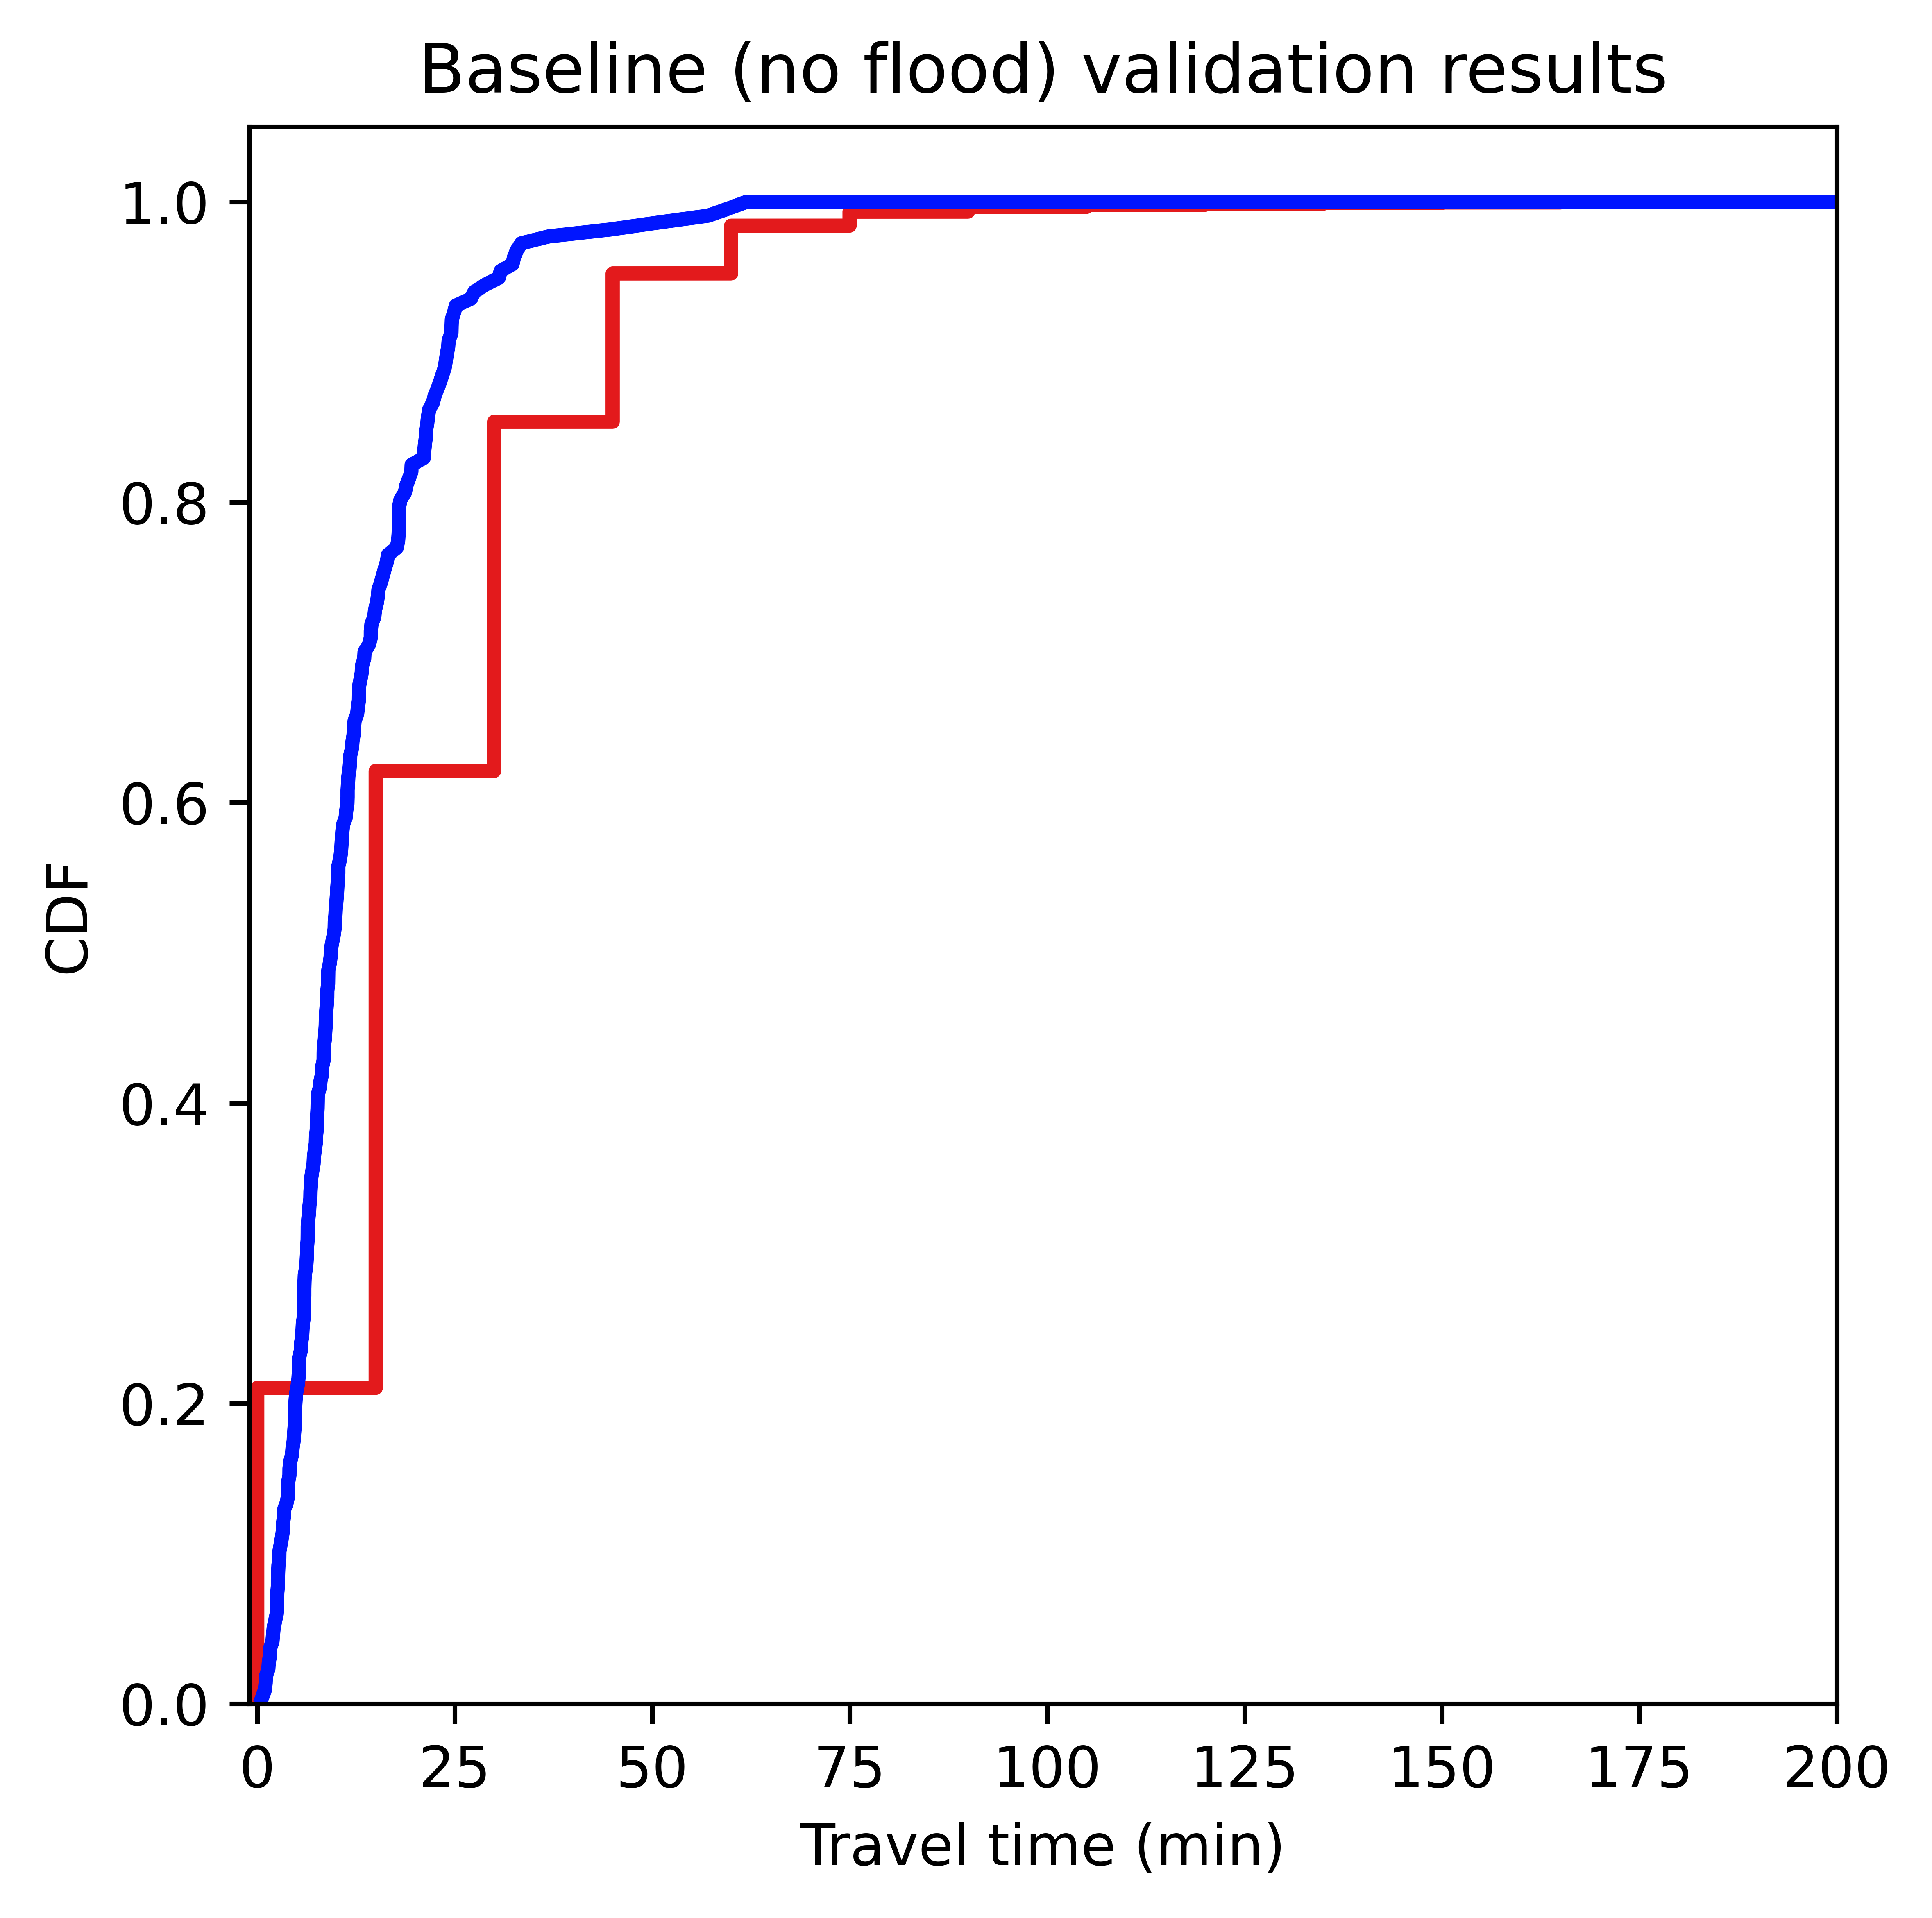

In [7]:
# Set max travel duration (minutes)
max_min = 300

fig = plt.figure(dpi=1000, figsize=(5,5))
ax = fig.add_subplot(111)
# Amap data
ax.plot(Amap_baseline_df["dur_time"], Amap_baseline_df["trip_num_cusum"], label="Amap", color="#e31a1c", linewidth=2.5)
plt.ylabel("CDF")
plt.xlabel("Travel time (min)")
plt.title("Baseline (no flood) validation results")

# Simulation
duration_series = pd.concat(
    [
        OD_baseline_df["OD_route_time_min"],
        pd.Series(range(round(OD_baseline_df["OD_route_time_min"].max()), max_min))
    ],
    ignore_index=True
)

cdf_series = pd.concat(
    [
        OD_baseline_df["trip_num_cusum"],
        pd.Series([1] * pd.Series(range(round(OD_baseline_df["OD_route_time_min"].max()), max_min)).shape[0])
    ],
    ignore_index=True
)
ax.plot(duration_series, cdf_series, label="Simulation", color="#0015ff", linewidth=2.5)

plt.xlim(-1, 200)
plt.ylim(0, 1.05)

##### KS test-baseline

In [23]:
from scipy.stats import ks_2samp
sample1 = []
for i in range(len(Amap_baseline_df)):
    sample1.extend( [Amap_baseline_df['dur_time'].iloc[i]] * round((Amap_baseline_df['cnt'].iloc[i])) )

sample2 = list(OD_baseline_df["OD_route_time_min"])
print(ks_2samp(sample1, sample2))

KstestResult(statistic=np.float64(0.5178109402129565), pvalue=np.float64(1.306752232056232e-54), statistic_location=np.float64(14.907612410115599), statistic_sign=np.int8(-1))


#### 5.2 Flooded scenario

(0.0, 1.05)

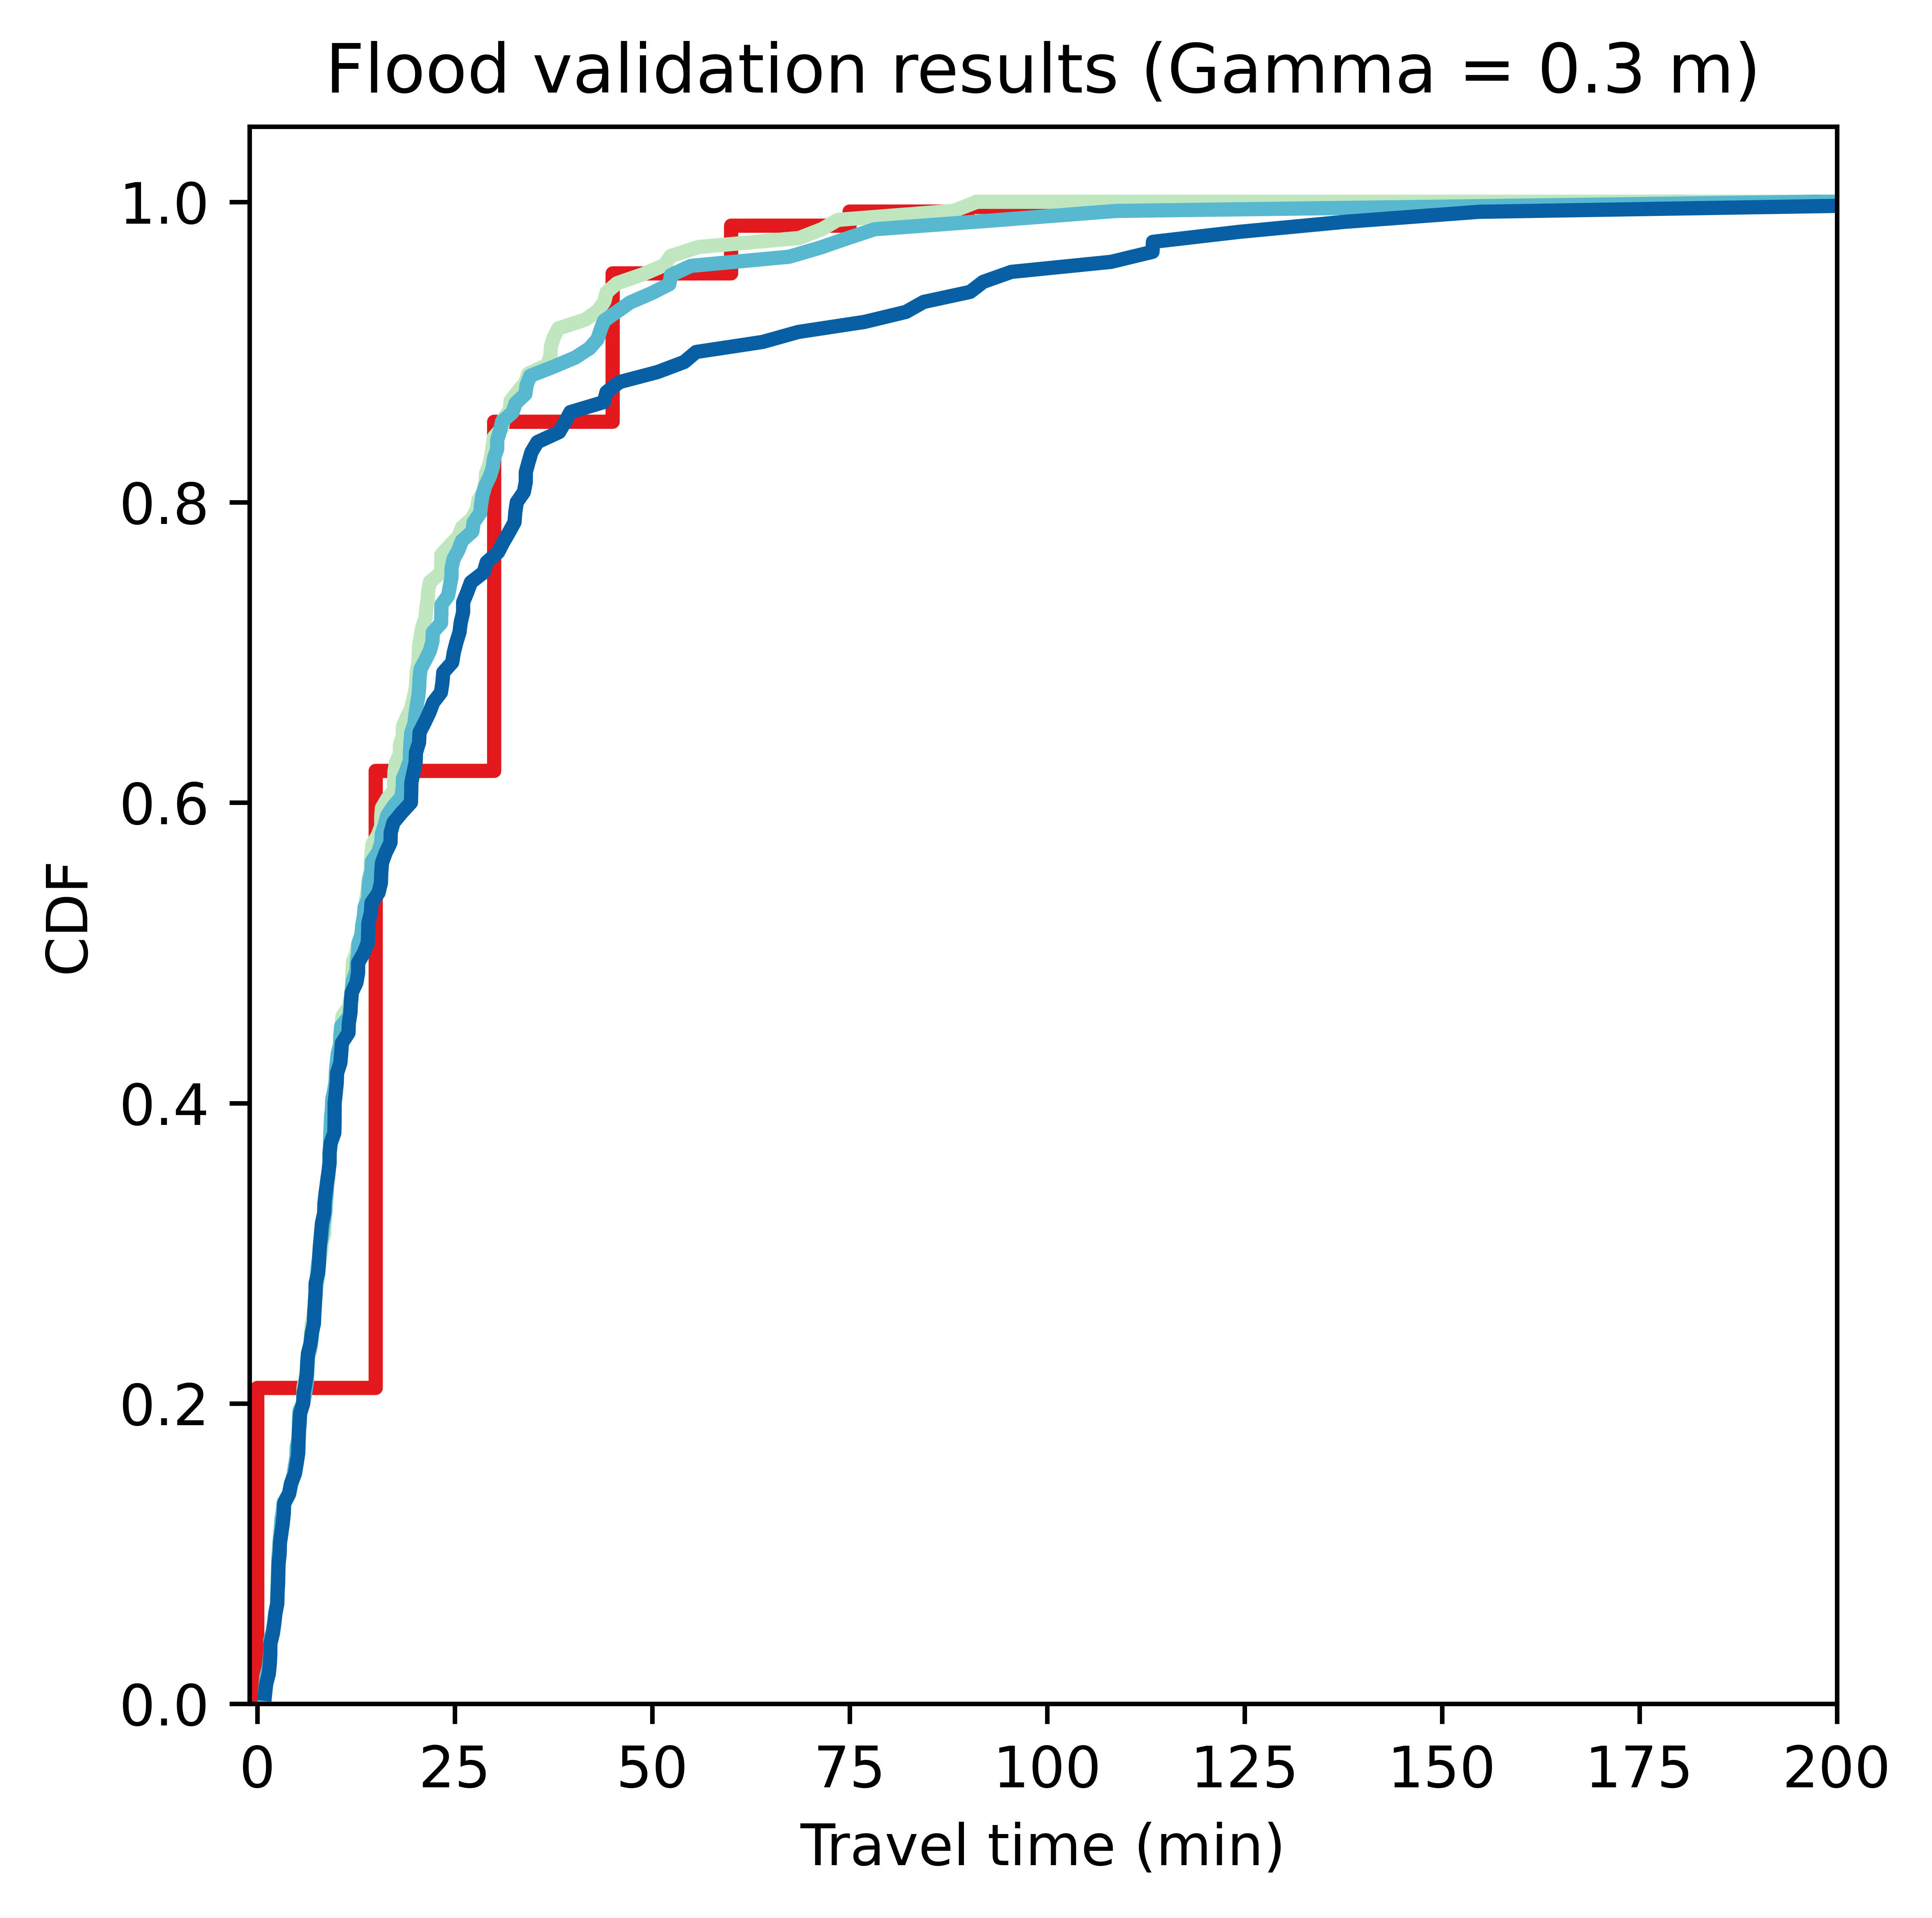

In [21]:
import matplotlib.cm as cm

### Ground truth from Amap
Amap_flood_df = od_df_amap_cleaned[od_df_amap_cleaned['ds'] == '20240711']  # Flood scenario
Amap_flood_df = Amap_flood_df.sort_values(by="dur_time", ascending=True).reset_index(drop=True)
Amap_flood_df["trip_num_cusum"] = np.cumsum(Amap_flood_df["cnt"]) / max(np.cumsum(Amap_flood_df["cnt"]))

### Simulation
gamma = 0.3 # critical inundation threshold
OD_flooded = pd.read_csv(home_dir + f'/Nanjing_validation/nj_OD_df_flood10_{gamma}.csv', index_col=0)

RP_lst = [5, 10, 20] # The flood event in 2024 July in Nanjing city is small one, therefore RPs greater than 50 are not considered

cmap = cm.GnBu # colormap
colors = cmap(np.linspace(0.3, 0.9, len(RP_lst)))  # select colors from color map

# calculate travel time/duration in minutes instead of seconds
for rp in RP_lst:
    OD_flooded[f'OD_time_min_FUP_{rp}_{gamma}'] = OD_flooded[f'OD_time_s_FUP_{rp}_{gamma}']/60

# plot figure
fig = plt.figure(dpi=1000, figsize=(5,5))
ax = fig.add_subplot(111)

# Amap data
ax.plot(Amap_baseline_df["dur_time"], Amap_baseline_df["trip_num_cusum"], label="Amap", color="#e31a1c", linewidth=2.5)
plt.ylabel("CDF")
plt.xlabel("Travel time (min)")
plt.title(f"Flood validation results (Gamma = {gamma} m)")

# simulation
# Set max travel duration (minutes)
max_min = 300
for rp, color in zip(RP_lst, colors):
    df = OD_flooded[OD_flooded[f'OD_time_min_FUP_{rp}_{gamma}'] != 0]
    df = df.sort_values(by=f"OD_time_min_FUP_{rp}_{gamma}", ascending=True).reset_index(drop=True)
    df['cnt'] = 1
    df['trip_num_cusum'] = np.cumsum(df["cnt"]) / max(np.cumsum(df["cnt"]))
    duration_series = pd.concat(
    [
        df[f"OD_time_min_FUP_{rp}_{gamma}"],
        pd.Series(range(round(df[f"OD_time_min_FUP_{rp}_{gamma}"].max()), max_min))
    ],
    ignore_index=True
    )

    cdf_series = pd.concat(
    [
        df["trip_num_cusum"],
        pd.Series([1] * pd.Series(range(round(df[f"OD_time_min_FUP_{rp}_{gamma}"].max()), max_min)).shape[0])
    ],
    ignore_index=True
    )
    ax.plot(duration_series, cdf_series, label=f"RP={rp}", linewidth=2.5, color = color)



plt.xlim(-1, 200)
plt.ylim(0, 1.05)

# plt.legend()

##### KS test-flood

In [22]:
gamma = 0.3

from scipy.stats import ks_2samp
sample1 = []
for i in range(len(Amap_flood_df)):
    sample1.extend( [Amap_flood_df['dur_time'].iloc[i]] * round((Amap_flood_df['cnt'].iloc[i])) )

for rp in [5, 10, 20]:
    OD_flooded[f'OD_time_min_FUP_{rp}_{gamma}'] = OD_flooded[f'OD_time_s_FUP_{rp}_{gamma}']/60
    df = OD_flooded[OD_flooded[f'OD_time_min_FUP_{rp}_{gamma}'] != 0]
    df = df.sort_values(by=f"OD_time_min_FUP_{rp}_{gamma}", ascending=True).reset_index(drop=True)
    sample2 = list(df[f"OD_time_min_FUP_{rp}_{gamma}"])
    print(f"RP = {rp}")
    print(ks_2samp(sample1, sample2))

RP = 5
KstestResult(statistic=np.float64(0.3687995531493342), pvalue=np.float64(9.26210434575381e-21), statistic_location=np.float64(14.595432091287414), statistic_sign=np.int8(-1))
RP = 10
KstestResult(statistic=np.float64(0.3574860062789258), pvalue=np.float64(2.88340386871264e-19), statistic_location=np.float64(14.537979547067815), statistic_sign=np.int8(-1))
RP = 20
KstestResult(statistic=np.float64(0.3298437298561615), pvalue=np.float64(4.847334839908752e-15), statistic_location=np.float64(14.470162752138792), statistic_sign=np.int8(-1))


## **LA**: Empirical validation with observed travel radius changes during flood events

### Step 1: Build network model

In [258]:
# Define coordinate reference system: WGS84 - World Geodetic System 1984 used in GPS
crs_lonlat = {'init': 'epsg:' + str(4326)}

# Read in the shapefile with the convex hulls of the settlement cluster boundaries
LA_bnd_shp = gpd.read_file(home_dir + '/LA_validation/LA_bnd/LA_bnd.shp').to_crs(crs_lonlat)

# Extract OSM road network for LA county (continental)
poly = LA_bnd_shp.geometry.iloc[0]
G = ox.graph_from_polygon(poly, network_type='drive_service')
with open(home_dir + '/LA_validation/LA_raw_drive.pk', 'wb') as handle:
    pickle.dump(G, handle, protocol=2)

/opt/miniconda3/envs/global0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [259]:
# Function to remove list nestings in highway road classes
def removeNestings(l): 
    output = []
    for i in l: 
        if type(i) == list: 
            output.extend(removeNestings(i))  # Use extend to add flattened results
        else: 
            output.append(i)
    return output

# Highway class unique values
highway_class_dict = nx.get_edge_attributes(G,'highway')
highway_class_lst = []
for item in highway_class_dict.values():
    highway_class_lst.append(item)

In [265]:
set(removeNestings(highway_class_lst))

{'busway',
 'emergency_bay',
 'escape',
 'living_street',
 'motorway',
 'motorway_link',
 'primary',
 'primary_link',
 'residential',
 'road',
 'secondary',
 'secondary_link',
 'service',
 'tertiary',
 'tertiary_link',
 'trunk',
 'trunk_link',
 'unclassified'}

In [267]:
# Identify highway classes to remove
highway_classes_to_remove = [
    'busway',
    'emergency_bay',
    'escape',
    'living_street',
    'residential',
    'road',
    'service',
    'tertiary',
    'tertiary_link',
    'unclassified'
    ]

# Delete 'highway' classes that are not included in the scope of study
G_lite = G.copy()
for i,j,data in G.edges.data():
    highway_cls = data['highway']
    if highway_cls in highway_classes_to_remove:
        G_lite.remove_edge(i, j)

In [268]:
# Remove isolated nodes as a result of the edge removal
G_lite.remove_nodes_from(list(nx.isolates(G_lite)))
# Save resulting graph as pickle file
with open(home_dir + '/LA_validation/LA_lite.pk', 'wb') as handle:
    pickle.dump(G_lite, handle, protocol=2)

# Save as geopackage
ox.io.save_graph_geopackage(G_lite, home_dir + '/LA_validation/LA_lite.gpkg')

In [ ]:
# add elevation to each of the nodes, using the google elevation API, then calculate edge grades
G_lite = ox.elevation.add_node_elevations_google(G_lite, api_key='your api key here')
G_lite = ox.add_edge_grades(G_lite)

# Save as graphml
ox.io.save_graphml(G_lite, home_dir + '/LA_validation/LA_lite_elev.graphml')
# Save as geopackage
ox.io.save_graph_geopackage(G_lite, home_dir + "/LA_validation/LA_lite_elev.gpkg")

**Add travel speed and time**

In [305]:
# Load graph for LA
LA_flood_graph = nx.read_graphml(home_dir + '/LA_validation/LA_flood10.graphml')

In [ ]:
# Add travel speed while clean up the graph
def get_speed(value):
    """
    value: string like "30 mph" or "[30 mph, 45 mph]"
    returns: int (smallest speed)
    """
    # Find all numbers in the string
    nums = re.findall(r"\d+", value)

    # Convert all found numbers to integers
    speeds = [int(n) for n in nums]

    # Return min if multiple, or the only value if one
    return min(speeds) if speeds else None

def get_min_speed_from_highway(highway, speed_dict):
    """
    highway: could be a string ('primary') or a list-like string ('["primary","secondary"]')
             or an actual list ['primary','secondary']
    speed_dict: your highway_ms_dict
    """
    # Convert list-like string to list
    if isinstance(highway, str) and highway.startswith('['):
        try:
            highway_list = ast.literal_eval(highway)
        except:
            highway_list = [highway]
    elif isinstance(highway, str):
        highway_list = [highway]
    else:
        # Already a list
        highway_list = list(highway)

    # Keep only those that appear in the speed dictionary
    valid_classes = [h for h in highway_list if h in speed_dict]

    if not valid_classes:
        return None   # Means: no matching class → edge should be removed

    # Return the smallest speed value among matched classes
    return min(speed_dict[h] for h in valid_classes)

highway_lst = []
highway_ms_dict = {
        'motorway': 33.33, # m/s =120kph
        'motorway_link': 33.33, #m/s =120kph
        'trunk': 27.78, #m/s =100kph
        'trunk_link': 27.78, #m/s =100kph
        'primary': 25, #m/s =90kph
        'primary_link': 25, #m/s =90kph
        'secondary': 22.22, #m/s =80kph
        'secondary_link': 22.22, #m/s =80kph
        'tertiary': 16.67, #m/s =60kph
        'tertiary_link': 16.67 #m/s =60kph
    }
edges_to_remove = []
# Assign travel speed value ("ms" m/s) for all edges
for i,j, data in LA_flood_graph.edges.data():
    # check if attribute 'maxspeed' exist or not
    if 'maxspeed' in data:
        # now entries could be 'x mph' or '['30 mph', '45 mph']'
        speed_mps = get_speed(data['maxspeed'])* 0.44704 # convert mph to m/s
        data['ms'] = speed_mps
    else: # if 'maxspeed' not available in attribute
        # check highway type
        highway_type = data['highway']
        speed_ms = get_min_speed_from_highway(highway_type, highway_ms_dict)
        if speed_ms is None:
            edges_to_remove.append((i,j))
        else:
            data["ms"] = speed_ms
LA_flood_graph.remove_edges_from(edges_to_remove) # remove edges that do not belong to the designated types for the study

In [ ]:
# Remove residential and service roads
edges_to_remove = []
for i,j,data in LA_flood_graph.edges.data():
    if data['highway'] in ['residential', 'service']:
        edges_to_remove.append((i,j))

LA_flood_graph.remove_edges_from(edges_to_remove)

Calculate travel time

In [ ]:
for i,j,data in LA_flood_graph.edges.data():
    data['travel_time'] = float(data['length'])/data['ms'] # unit: seconds

In [322]:
# Save as graphml
nx.write_graphml(LA_flood_graph, home_dir + '/LA_validation/LA_lite_elev_flood_speed_time.graphml')

In [ ]:
# Save as a pickle file
with open(home_dir + '/LA_validation/LA_lite_elev_flood_speed_time.pk', 'wb') as handle:
    pickle.dump(LA_flood_graph, handle, protocol=2)

### Step 2: Dry condition routing (baseline)

In [324]:
# Load network/graph with edge speed and travel time
LA_graph = pickle.load(open(home_dir + '/LA_validation/LA_lite_elev_flood_speed_time.pk', 'rb'))

In [446]:
# dry simulation
# Load node probability
node_pop_prob = pd.read_csv(home_dir + '/LA_validation/la_pop_probability.csv', index_col=0)
# Only keep nodes that is matches the ones in the graph
la_graph_node_lst = list(map(int, list(LA_graph.nodes())))
node_pop_prob_filtered = node_pop_prob[node_pop_prob['osmid'].isin(la_graph_node_lst)]

# List of node osmnid and corresponding sample probability
node_osmid_lst = list(map(int, node_pop_prob_filtered.osmid.values))
node_prob_lst_raw = list(node_pop_prob_filtered.pop_probability.values)
node_prob_lst = [0 if isinstance(x, float) and math.isnan(x) else x for x in node_prob_lst_raw] # replace nan with zero

# Select nodes from simplified list
simplified_nodes_df = pd.read_csv(home_dir + "/LA_validation/simplified_pts.csv", index_col=0)

allowed = set(simplified_nodes_df.osmid.values) # simplified osmids

filtered_nodes = []
filtered_probs = []

for node, prob in zip(node_osmid_lst, node_prob_lst):
    if node in allowed:
        filtered_nodes.append(node)
        filtered_probs.append(prob)

# Normalize probabilities
total = sum(filtered_probs)
filtered_probs = [p / total for p in filtered_probs]

# Initiate dataframe to store route simulation results
OD_df = pd.DataFrame(columns=[  'index',
                                'O_node_id',
                                'D_node_id',
                                'OD_route',
                                'OD_route_time_s',
                                'rad_meter'])

epsilon = float('inf')
travel_time_lst = []
index = 0

while epsilon > 0.00001:
    # Sample origin
    sample_O_pt = random.choices(filtered_nodes, filtered_probs)[0]
    sample_D_pt = random.choices(filtered_nodes, filtered_probs)[0]
    while sample_O_pt == sample_D_pt:
            sample_D_pt = random.choices(filtered_nodes, filtered_probs)[0]
    
    # Haversine distance between OD
    O_lat = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_O_pt, "y"].values[0]
    O_lon = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_O_pt, "x"].values[0]

    D_lat = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_D_pt, "y"].values[0]
    D_lon = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_D_pt, "x"].values[0]

    rad = haversine(
          (O_lat, O_lon),
          (D_lat, D_lon),
          unit=Unit.METERS
    )

    #
    try:
        OD_route = nx.shortest_path(LA_graph.to_undirected(), str(sample_O_pt), str(sample_D_pt), weight='travel_time') # route
        OD_route_time = nx.shortest_path_length(LA_graph.to_undirected(), str(sample_O_pt), str(sample_D_pt), weight='travel_time') # seconds
        travel_time_lst.append(OD_route_time)
    
        OD_df.loc[index] = [index+1, sample_O_pt, sample_D_pt, OD_route, OD_route_time, rad]

        if len(travel_time_lst) == 1:
                epsilon = float('inf')
        else:
                epsilon = abs(np.mean(travel_time_lst) - np.mean(travel_time_lst[:-1]))

        index += 1
    except nx.NetworkXNoPath:
        continue

OD_df.to_csv(home_dir + '/LA_validation/la_OD_df_e5.csv')

/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/3644297794.py:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  node_pop_prob = pd.read_csv(home_dir + '/LA_validation/la_pop_probability.csv', index_col=0)


### Step 3: Wet condition routing (flooded)

##### 3.1 Generate disrupted graphs under 10 return periods and 4 inundation thresholds (gamma = 0.3, 0.25, 0.2, 0.15, unit:meters)

In [638]:
# Load graph for LA
LA_flood_graph = nx.read_graphml(home_dir + '/LA_validation/LA_output_addnodes.graphml')

# Re-Assign travel speed value ("ms" m/s) for all edges
for i,j, data in LA_flood_graph.edges.data():
    # check if attribute 'maxspeed' exist or not
    if 'maxspeed' in data:
        # now entries could be 'x mph' or '['30 mph', '45 mph']'
        speed_mps = get_speed(data['maxspeed'])* 0.44704 # convert mph to m/s
        data['ms'] = speed_mps
    else: # if 'maxspeed' not available in attribute
        # check highway type
        highway_type = data['highway']
        speed_ms = get_min_speed_from_highway(highway_type, highway_ms_dict)
        if speed_ms is None:
            edges_to_remove.append((i,j))
        else:
            data["ms"] = speed_ms

flooded_graphs_dir = home_dir + '/LA_validation/flooded_graphs' # folder to store disrupted graphs

# Critical inundation thresholds
gamma_lst = [0.3, 0.25, 0.2, 0.15]

# List of flood return periods
RP_lst = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]

# Loop through the return periods
for rp in RP_lst:
    print('I am working on RP=' + str(rp))
    for gamma in gamma_lst:
        # Make a copy of the graph
        LA_graph_copy = LA_flood_graph.copy()
        # Delete nodes with flood inundation greater than critical inundation threshold, e.g., 30cm or 0.3m
        for node_id, node_data in LA_flood_graph.nodes.data():
            if node_data['FUP_max_rp' + str(rp)] >= gamma and node_data['FUP_max_rp' + str(rp)] < 99:
                LA_graph_copy.remove_node(node_id)

        # Remove residual service or residential edges
        edges_to_remove = []

        # Add flood travel speed
        for start_id, end_id, edge_data in LA_graph_copy.edges.data():
            edge_water_depth_m = max(LA_graph_copy.nodes[start_id]['FUP_max_rp'+str(rp)], LA_graph_copy.nodes[end_id]['FUP_max_rp'+str(rp)])
            edge_flood_depth_mm = edge_data['FUP_max_rp'+str(rp)]*1000 # unit:mm
            try:
                designed_speed_ms = edge_data['ms'] # m/s
                theoretical_speed_ms = (86.9448 - (0.5529*edge_flood_depth_mm) + (0.0009*edge_flood_depth_mm*edge_flood_depth_mm))/3.6 # m/s
                speed_final = min(theoretical_speed_ms, designed_speed_ms)
                LA_graph_copy[start_id][end_id][0]['speed_ms_rp'+ str(rp) + "_" + str(gamma)] = speed_final
                LA_graph_copy[start_id][end_id][0]['time_s_rp'+ str(rp) + "_" + str(gamma)] = float(edge_data['length'])/speed_final
            except KeyError:
                    # Remove residential and service roads
                    edges_to_remove.append((start_id, end_id))

        LA_flood_graph.remove_edges_from(edges_to_remove)
        with open(flooded_graphs_dir + '/LA_graph_disrupted_FUP_' + str(rp) + "_" + str(gamma)+ '.pk', 'wb') as handle:
            pickle.dump(LA_graph_copy, handle, protocol=2)

I am working on RP=5
I am working on RP=10
I am working on RP=20
I am working on RP=50
I am working on RP=75
I am working on RP=100
I am working on RP=200
I am working on RP=250
I am working on RP=500
I am working on RP=1000


#### 3.2 Wet routing

In [ ]:
# Gamma = 0.3 meters
gamma = 0.3

# Load OD pairs from dry routing
OD_baseline = pd.read_csv(home_dir + '/LA_validation/la_OD_df_e5.csv', index_col=0) # 'rad_meter': travel radius in meters

# Load disrupted graph
RP_lst = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
for rp in RP_lst:
    print(f"I am working on rp={rp}")
    wet_OD_df = OD_baseline.copy()
    # Initiate column to store new route
    wet_OD_df[f'OD_route_FUP_{rp}_{gamma}'] = None
    wet_OD_df[f'OD_time_s_FUP_{rp}_{gamma}'] = 0

    # Load disrupted graph
    LA_graph = pickle.load(open(home_dir + '/LA_validation/flooded_graphs' + '/LA_graph_disrupted_FUP_' + str(rp) + "_" + str(gamma)+ '.pk', 'rb'))

    # Run travel simulation between OD pairs
    for row_idx in tqdm(range(wet_OD_df.shape[0])):
        O_node_id = wet_OD_df.iloc[row_idx]['O_node_id']
        D_node_id = wet_OD_df.iloc[row_idx]['D_node_id']

        try:
            wet_OD_route = nx.shortest_path(LA_graph.to_undirected(), str(O_node_id), str(D_node_id), weight=f'time_s_rp{rp}_{gamma}') # route
            wet_OD_route_time = nx.shortest_path_length(LA_graph.to_undirected(), str(O_node_id), str(D_node_id), weight=f'time_s_rp{rp}_{gamma}') # seconds

            wet_OD_df.at[row_idx, f'OD_route_FUP_{rp}_{gamma}'] = wet_OD_route
            wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
        except:
            continue
    wet_OD_df.to_csv(home_dir + f'/LA_validation/flood_simulation/LA_OD_df_flood_rp{rp}_{gamma}.csv')

I am working on rp=250


  0%|          | 0/13264 [00:00<?, ?it/s]/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_2738/1094722799.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3307.15713165397' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
  0%|          | 3/13264 [00:08<10:51:45,  2.95s/it]

### Step 4: Process Safegraph dataset

In [256]:
# folder where Safegraph OD trip dataset is stored
LA_safegraph_dir = home_dir + '/LA_validation/LA_wpw/Real Mobility Data/'

# Dates for baseline and flood scenarios
date_baselines = ["2019_01_07", "2019_02_07", "2019_02_27", "2019_11_13", "2019_11_27", "2019_12_16"]
date_floodings = ["2019_01_14", "2019_02_14", "2019_03_06", "2019_11_20", "2019_12_04", "2019_12_23"]

# compile baseline scenario dataframe
baseline_sg_df_lst = []
for date in date_baselines:
    date_df = pd.read_csv(LA_safegraph_dir + f'{date}_merge_la.csv') # dis: distance in km
    baseline_sg_df_lst.append(date_df)

# compile flood scenario dataframe
flood_sg_df_lst = []
for date in date_floodings:
    date_df = pd.read_csv(LA_safegraph_dir + f'{date}_merge_la.csv') # dis: distance in km
    flood_sg_df_lst.append(date_df)

# Create compiled dataframes for both scenarios
baseline_sg_df = pd.concat(baseline_sg_df_lst, ignore_index=True)
flood_sg_df = pd.concat(flood_sg_df_lst, ignore_index=True)

# Remove OD points in the islands
remove_ids = {6037599000, 6037599100, 6037990200,
              6037297601, 6037980031, 6037980033,
              6037576001, 6037576700, 6037577200,
              6037576602, 6037577300, 6037577504,
              6037577501} # geoid of the two points on the islands or does not overlap with LA county boundary

baseline_sg_df = baseline_sg_df[
    ~baseline_sg_df["geoid_o"].isin(remove_ids) &
    ~baseline_sg_df["geoid_d"].isin(remove_ids)
]

flood_sg_df = flood_sg_df[
    ~flood_sg_df["geoid_o"].isin(remove_ids) &
    ~flood_sg_df["geoid_d"].isin(remove_ids)
]

# Save as new csv files
baseline_sg_df.to_csv(LA_safegraph_dir + 'LA_baseline_SG.csv')
flood_sg_df.to_csv(LA_safegraph_dir + 'LA_flood_SG.csv')

### Step 5: Validation

#### 5.1 Baseline scenario

In [9]:
'''SafeGraph'''
# Load safegraph dataframe
baseline_sg_df = pd.read_csv(home_dir + '/LA_validation/LA_wpw/Real Mobility Data/LA_baseline_SG.csv', index_col=0) # 'dis': radius in km
baseline_sg_df['cnt'] = 1
baseline_sg_df = baseline_sg_df.sort_values(by="dis", ascending=True).reset_index(drop=True) # sort by trip radius
baseline_sg_df['trip_rad_cusum'] = np.cumsum(baseline_sg_df["cnt"]) / max(np.cumsum(baseline_sg_df["cnt"]))

'''Simulation'''
# Load simulation dataframe
baseline_la_sim = pd.read_csv(home_dir + '/LA_validation/la_OD_df_e5.csv', index_col=0) # 'rad_meter': travel radius in meters
baseline_la_sim['rad_km'] = baseline_la_sim['rad_meter']/1000 # convert from meter to km
baseline_la_sim['cnt'] = 1 # add cnt column
baseline_la_sim = baseline_la_sim.sort_values(by='rad_km', ascending=True).reset_index(drop=True)
baseline_la_sim['trip_rad_cusum'] = np.cumsum(baseline_la_sim["cnt"]) / max(np.cumsum(baseline_la_sim["cnt"]))

(0.0, 1.05)

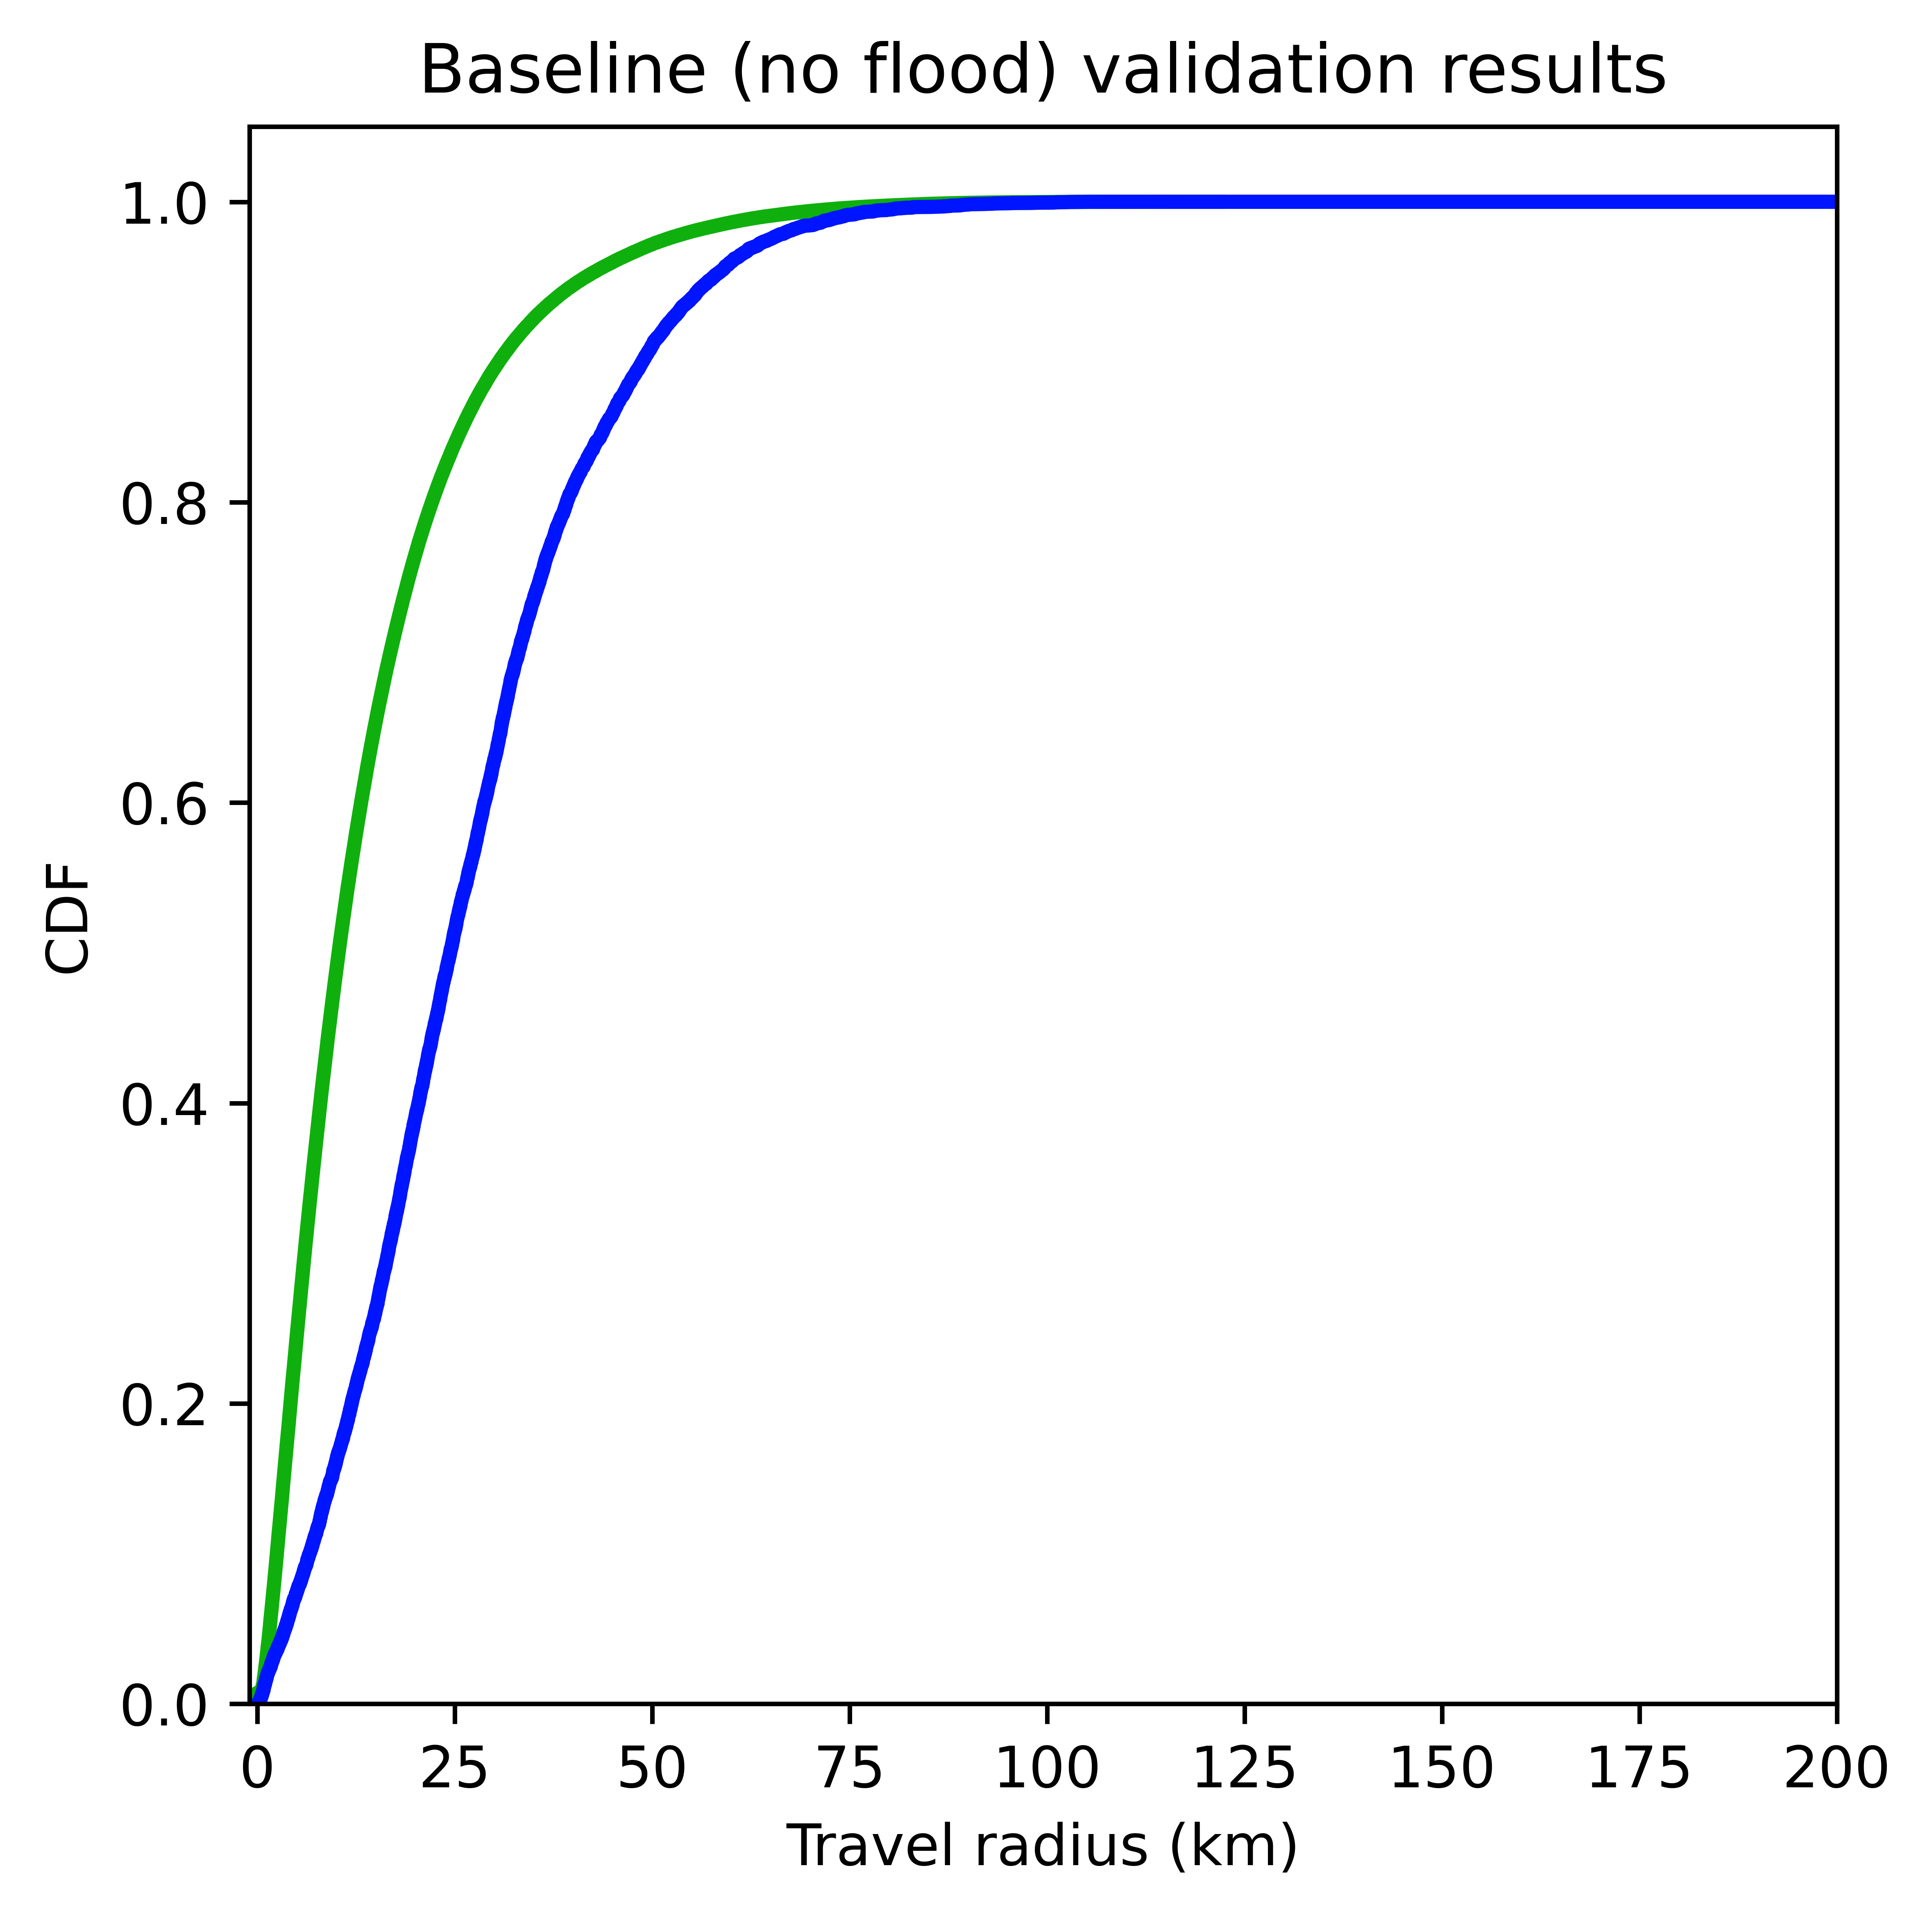

In [620]:
# Set max travel duration (minutes)
max_min = 200

fig = plt.figure(dpi=1000, figsize=(5,5))
ax = fig.add_subplot(111)
# Safegraph travel radius data
ax.plot(baseline_sg_df["dis"], baseline_sg_df["trip_rad_cusum"], label="SafeGraph", color="#0FB00D", linewidth=2.5)
plt.ylabel("CDF")
plt.xlabel("Travel radius (km)")
plt.title("Baseline (no flood) validation results")

# # Simulation
duration_series = pd.concat(
    [
        baseline_la_sim["rad_km"],
        pd.Series(range(round(baseline_la_sim["rad_km"].max()), max_min))
    ],
    ignore_index=True
)

cdf_series = pd.concat(
    [
        baseline_la_sim["trip_rad_cusum"],
        pd.Series([1] * pd.Series(range(round(baseline_la_sim["rad_km"].max()), max_min)).shape[0])
    ],
    ignore_index=True
)
ax.plot(duration_series, cdf_series, label="Simulation", color="#0015ff", linewidth=2.5)

plt.xlim(-1, 200)
plt.ylim(0, 1.05)

In [619]:
from scipy.stats import ks_2samp
sample1 = []
for i in range(len(baseline_sg_df)):
    sample1.extend( [baseline_sg_df['dis'].iloc[i]] * round((baseline_sg_df['cnt'].iloc[i])) )

sample2 = list(baseline_la_sim["rad_km"])
print(ks_2samp(sample1, sample2))

KstestResult(statistic=np.float64(0.39416564819856603), pvalue=np.float64(0.0), statistic_location=np.float64(16.232616835120368), statistic_sign=np.int8(1))


#### 5.2 Flooded scenario

In [ ]:
'''SafeGraph'''
# Load safegraph dataframe
flood_sg_df = pd.read_csv(home_dir + '/LA_validation/LA_wpw/Real Mobility Data/LA_flood_SG.csv', index_col=0) # 'dis': radius in km
flood_sg_df['cnt'] = 1
flood_sg_df = flood_sg_df.sort_values(by="dis", ascending=True).reset_index(drop=True) # sort by trip radius
flood_sg_df['trip_rad_cusum'] = np.cumsum(flood_sg_df["cnt"]) / max(np.cumsum(flood_sg_df["cnt"]))

'''Simulation'''
# Load simulation dataframe
flood_sim_dir = home_dir + "/LA_validation/flood_simulation/"
RP_lst = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
gamma = 0.3

dfs = {} # create d
for rp in RP_lst:
    flood_df = pd.read_csv(flood_sim_dir + f"LA_OD_df_flood_rp{rp}_{gamma}.csv", index_col=0)
    # select records with none zero travel radius
    flood_df_sel = flood_df[flood_df[f'OD_time_s_FUP_{rp}_{gamma}'] != 0]
    flood_df_sel['rad_km'] = flood_df_sel['rad_meter']/1000 # convert from meter to km
    flood_df_sel['cnt'] = 1 # add cnt column
    flood_df_sel = flood_df_sel.sort_values(by='rad_km', ascending=True).reset_index(drop=True)
    flood_df_sel['trip_rad_cusum'] = np.cumsum(flood_df_sel["cnt"]) / max(np.cumsum(flood_df_sel["cnt"]))
    flood_df_sel['RP'] = rp

    dfs[rp] = flood_df_sel

(0.0, 1.05)

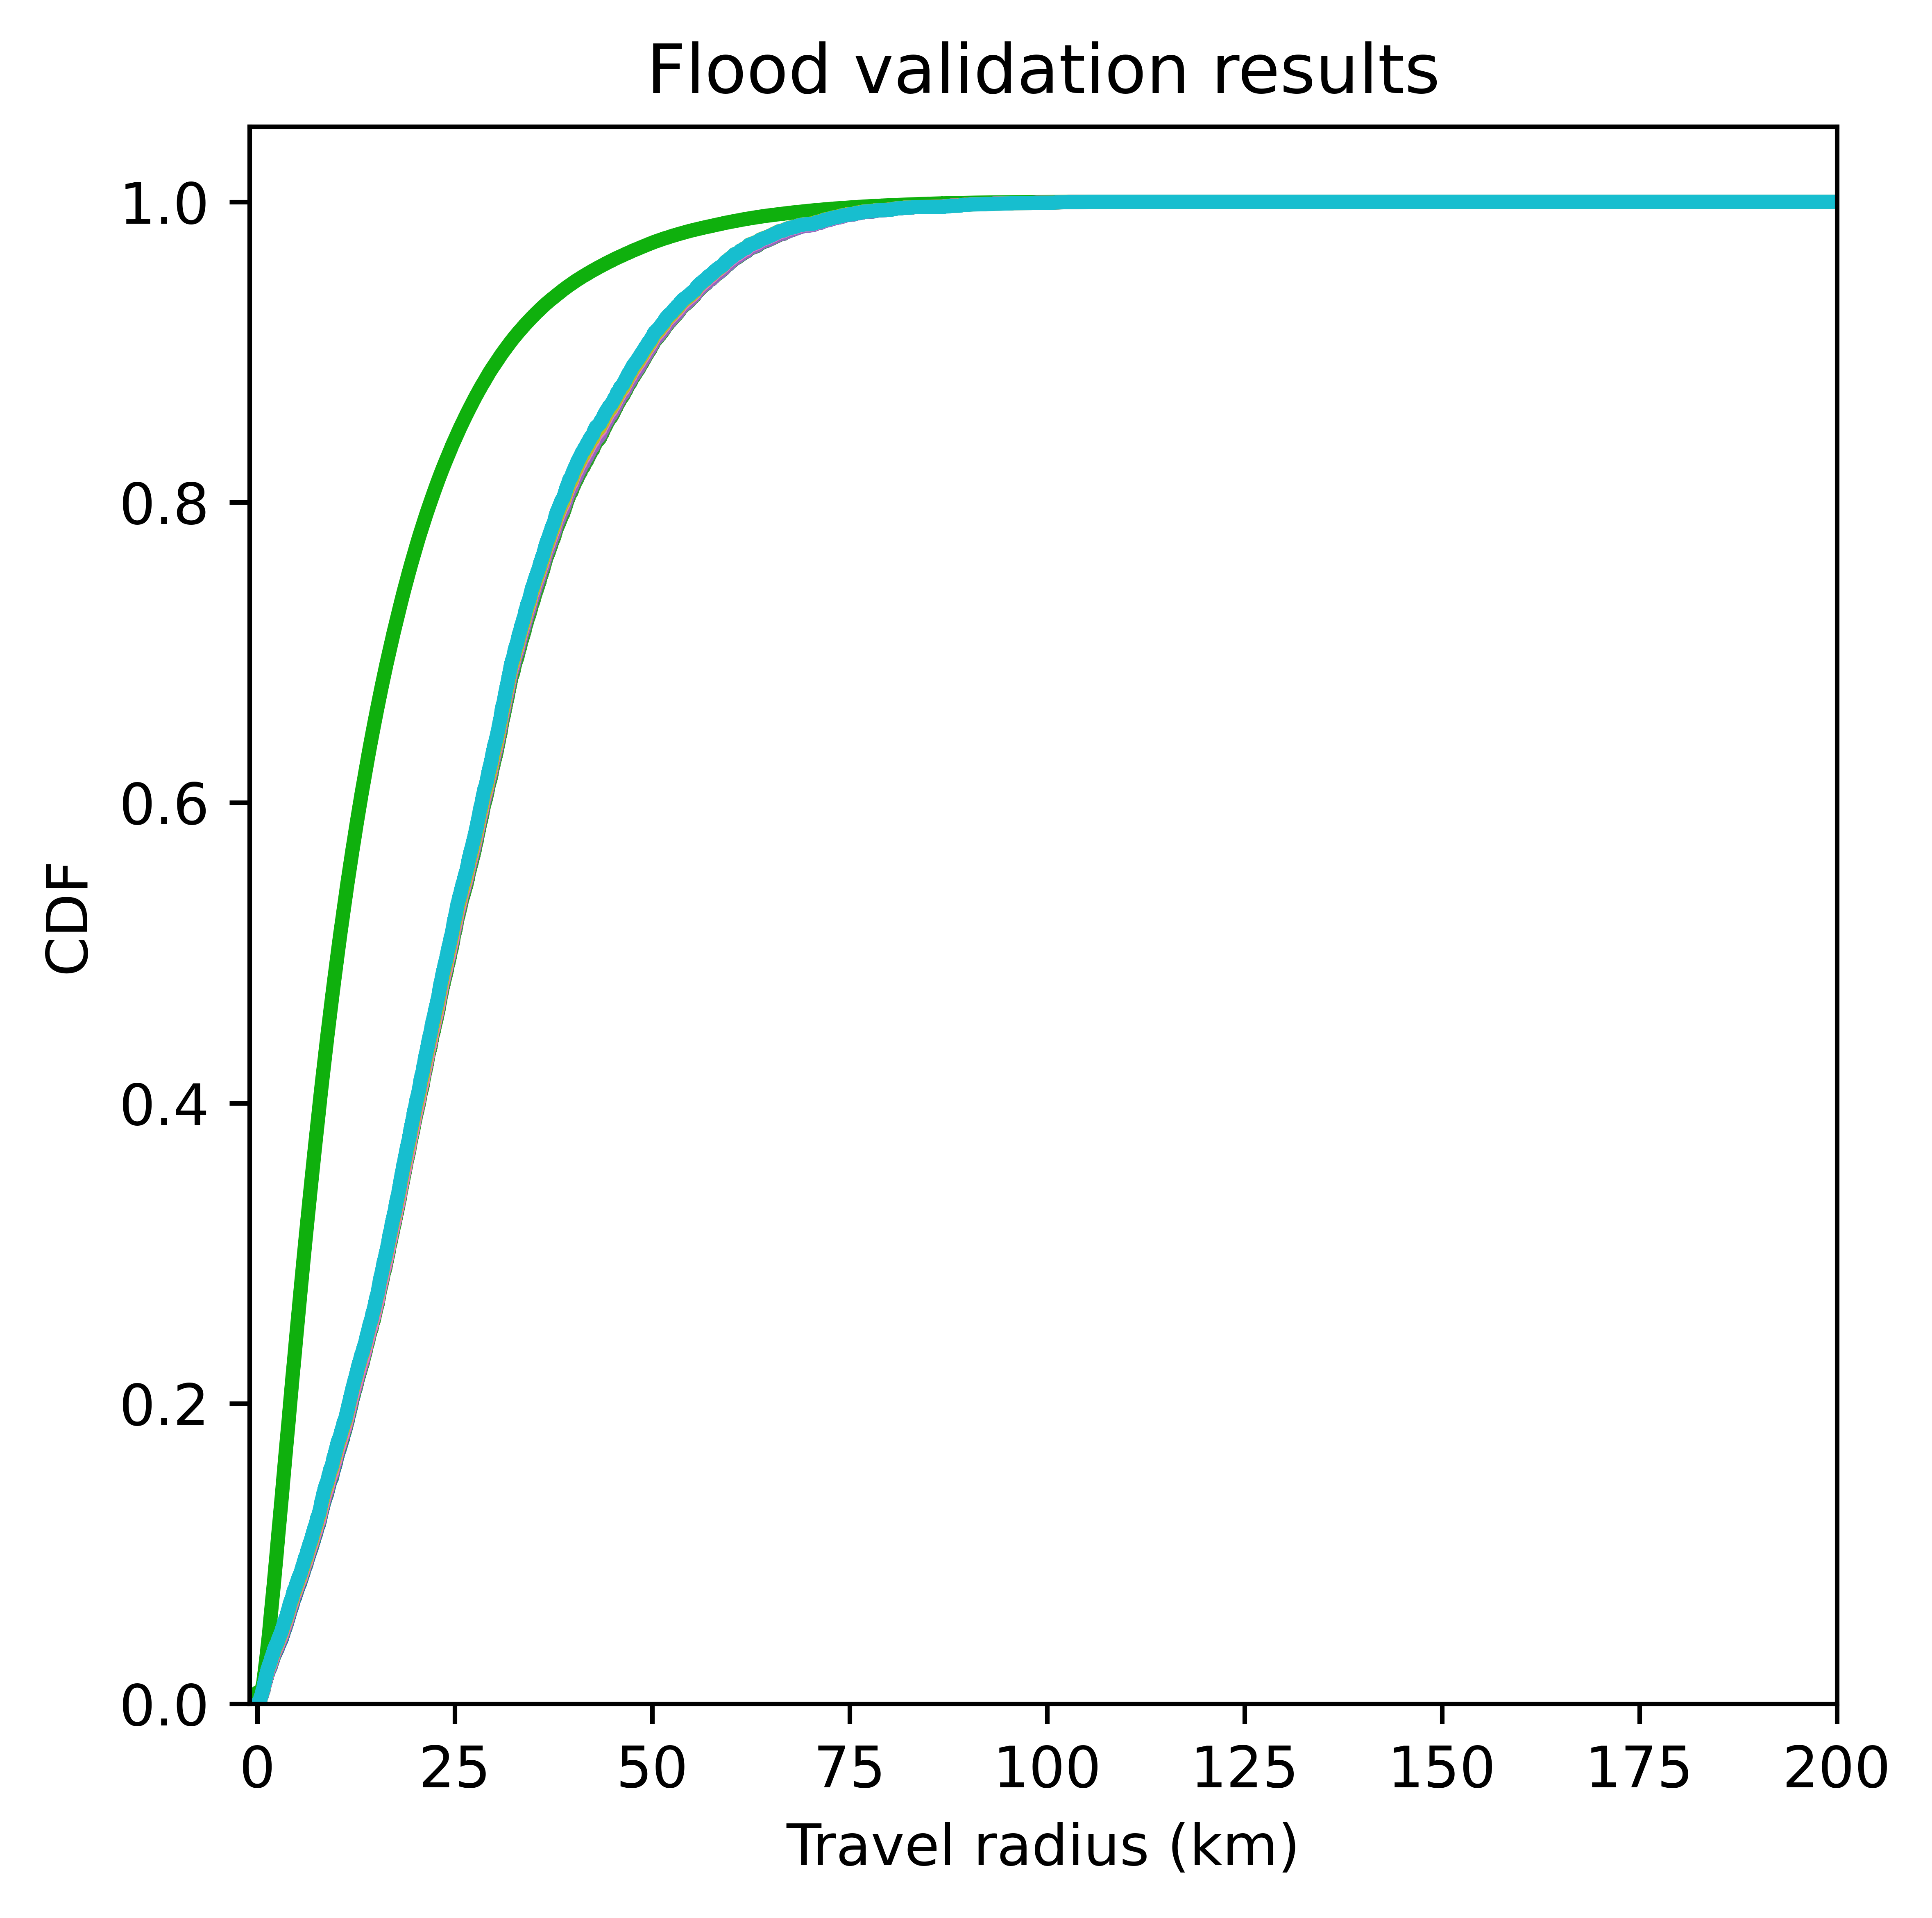

In [ ]:
'''Plot RPs = 5, 10, 20, 50, 75, 100'''
# Set max travel duration (minutes)
max_min = 200

fig = plt.figure(dpi=1000, figsize=(5,5))
ax = fig.add_subplot(111)
# Safegraph travel radius data
ax.plot(flood_sg_df["dis"], flood_sg_df["trip_rad_cusum"], label="SafeGraph", color="#0FB00D", linewidth=2.5)
plt.ylabel("CDF")
plt.xlabel("Travel radius (km)")
plt.title("Flood validation results")

RP_lst = [5, 10, 20, 50, 75, 100]
colors = plt.cm.tab10(np.linspace(0, 1, 6))   # good up to 10
for i, rp in enumerate(RP_lst):
    flood_df_sel = dfs[rp]
    # Simulation
    duration_series = pd.concat(
        [
            flood_df_sel["rad_km"],
            pd.Series(range(round(flood_df_sel["rad_km"].max()), max_min))
        ],
        ignore_index=True
    )

    cdf_series = pd.concat(
        [
            flood_df_sel["trip_rad_cusum"],
            pd.Series([1] * pd.Series(range(round(flood_df_sel["rad_km"].max()), max_min)).shape[0])
        ],
        ignore_index=True
    )
    ax.plot(duration_series, cdf_series, label="Simulation", color=colors[i], linewidth=2.5)

plt.xlim(-1, 200)
plt.ylim(0, 1.05)

(0.0, 1.05)

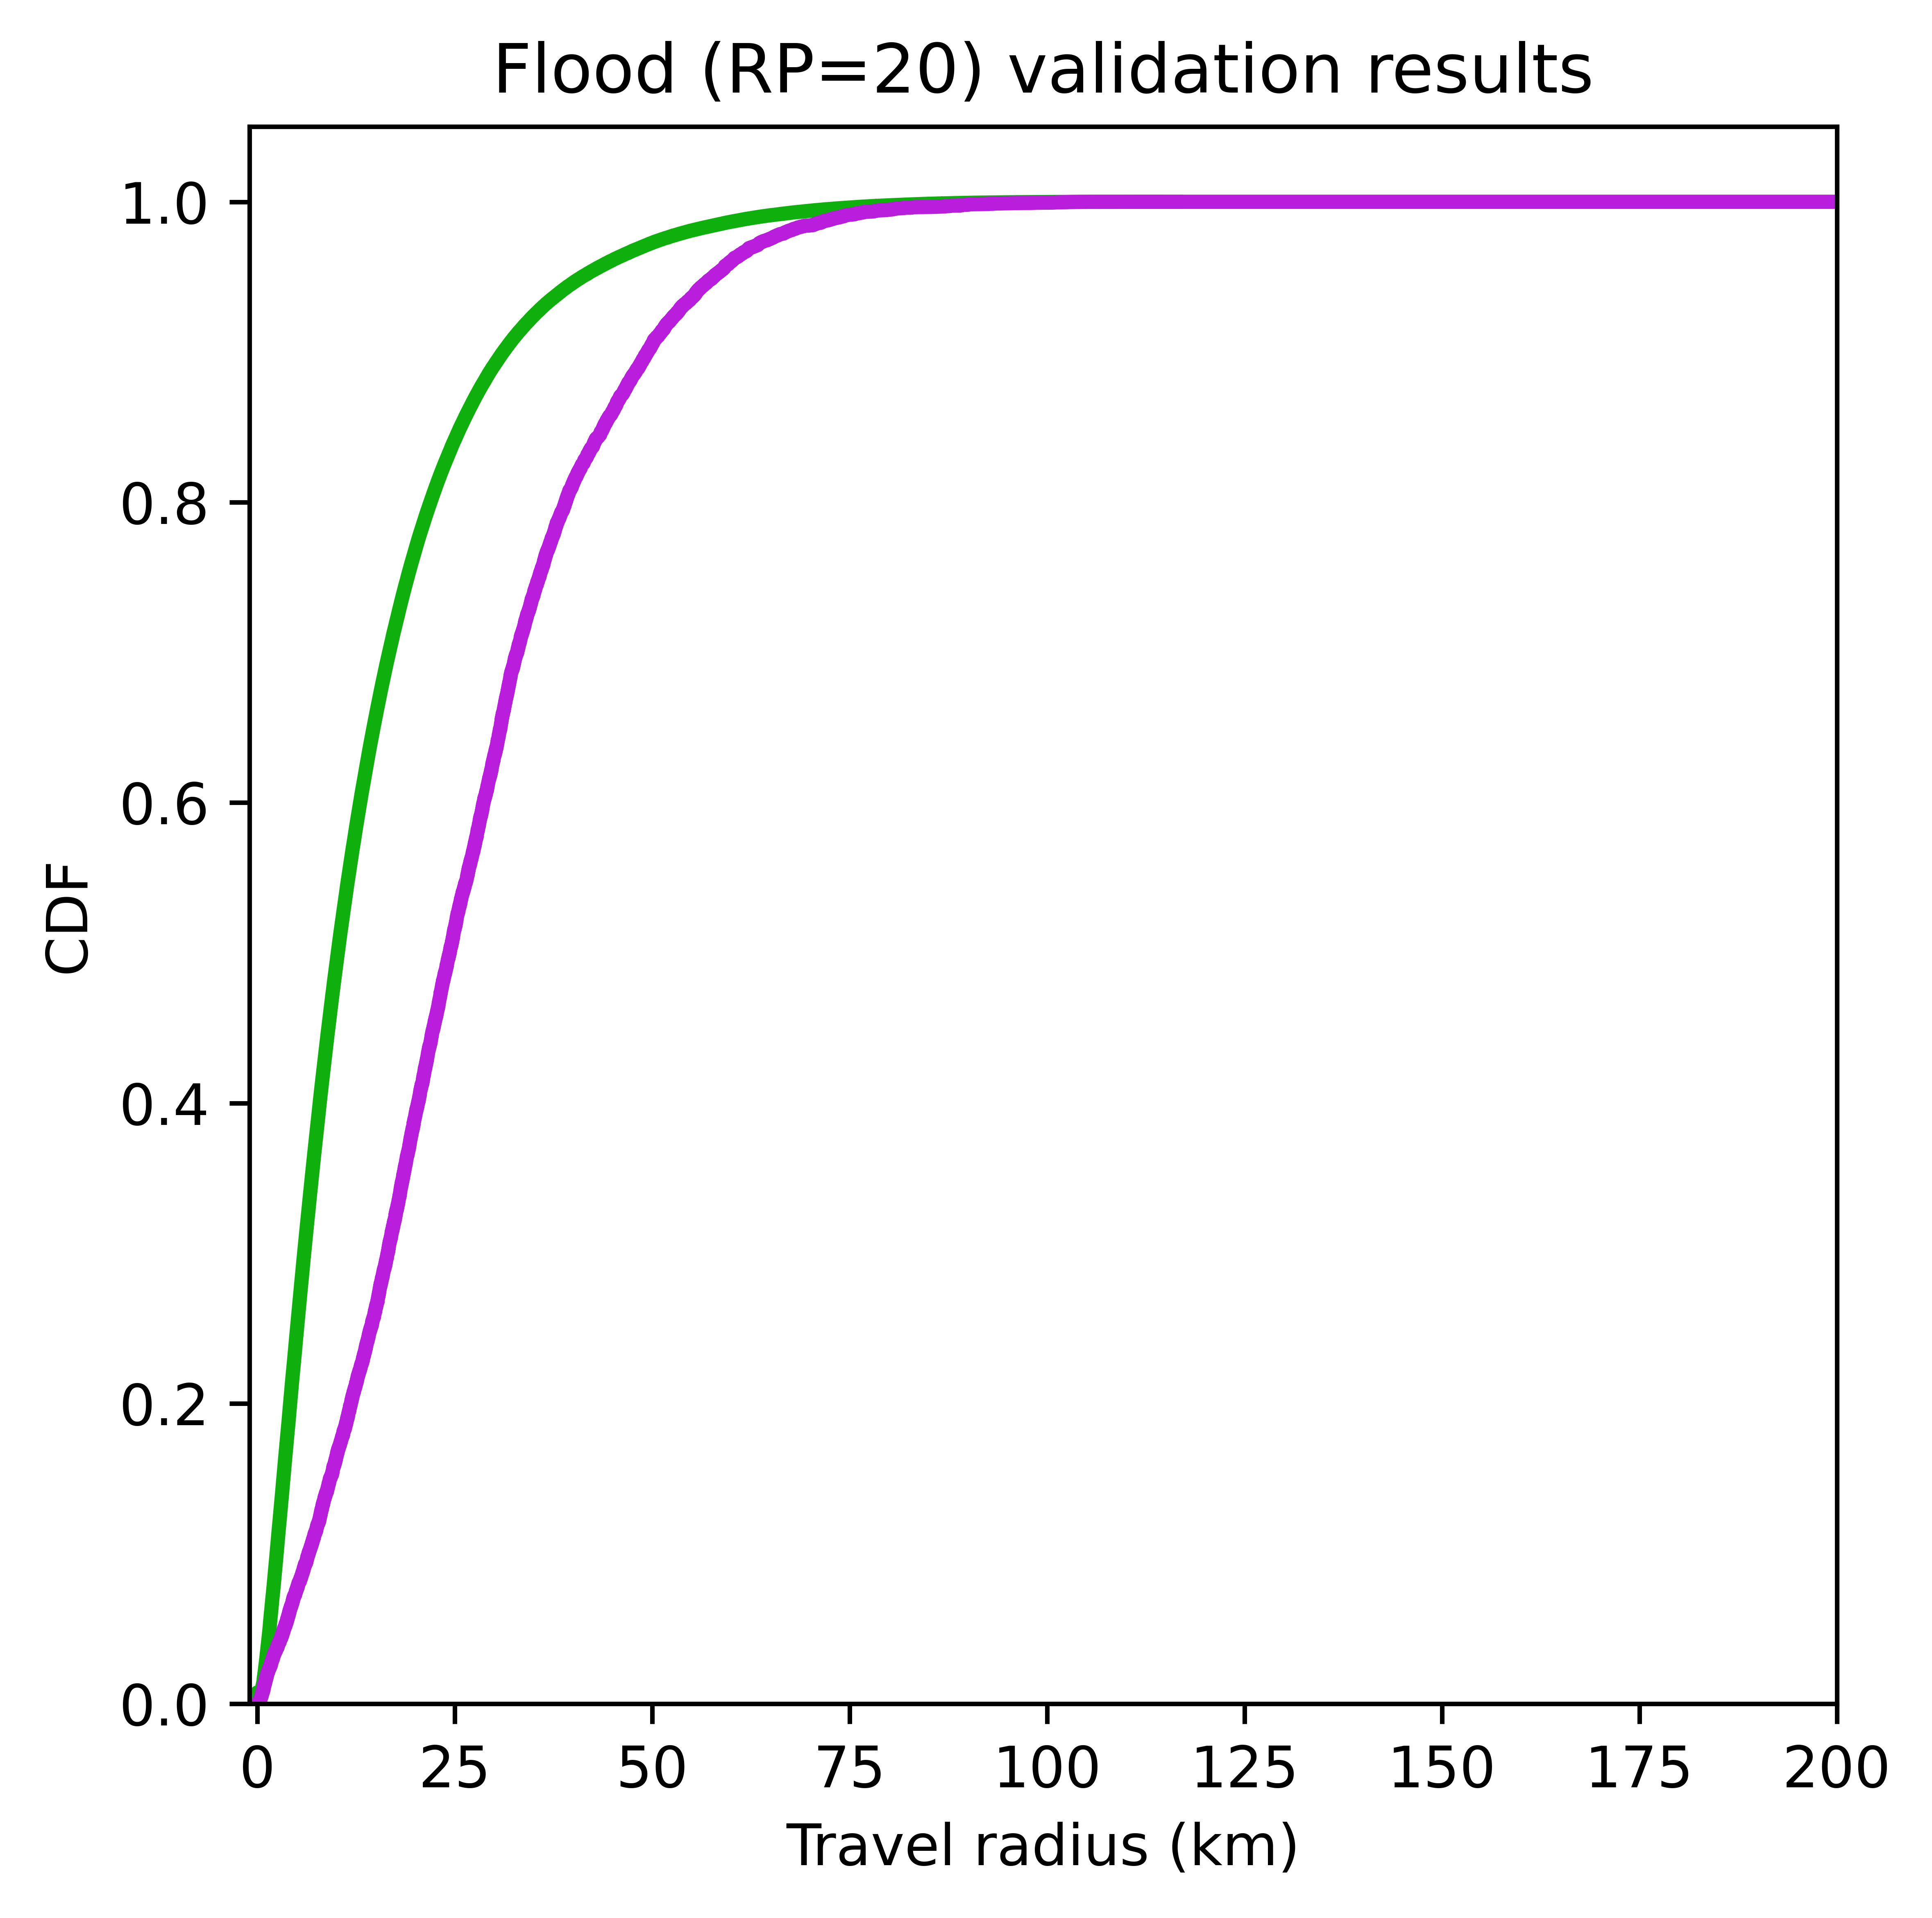

In [44]:
'''Plot RP = 20'''
# Set max travel duration (minutes)
max_min = 200
# Set return period
rp = 20

fig = plt.figure(dpi=1000, figsize=(5,5))
ax = fig.add_subplot(111)
# Safegraph travel radius data
ax.plot(flood_sg_df["dis"], flood_sg_df["trip_rad_cusum"], label="SafeGraph", color="#0FB00D", linewidth=2.5)
plt.ylabel("CDF")
plt.xlabel("Travel radius (km)")
plt.title(f"Flood (RP={rp}) validation results")

flood_df_sel = dfs[rp]
# Simulation
duration_series = pd.concat(
    [
        flood_df_sel["rad_km"],
        pd.Series(range(round(flood_df_sel["rad_km"].max()), max_min))
    ],
    ignore_index=True
)

cdf_series = pd.concat(
    [
        flood_df_sel["trip_rad_cusum"],
        pd.Series([1] * pd.Series(range(round(flood_df_sel["rad_km"].max()), max_min)).shape[0])
    ],
    ignore_index=True
)
ax.plot(duration_series, cdf_series, label="Simulation", color="#B91EDC", linewidth=2.5)

plt.xlim(-1, 200)
plt.ylim(0, 1.05)

## **Hamburg**: Empirical validation with observed travel time and radius records

### Step 1: Build network model

In [518]:
# Define coordinate reference system: WGS84 - World Geodetic System 1984 used in GPS
crs_lonlat = {'init': 'epsg:' + str(4326)}

# Read in the shapefile with the convex hulls of the settlement cluster boundaries
HH_bnd_shp = gpd.read_file(home_dir + '/Hamburg_validation/gis/hamburg_boundary.shp').to_crs(crs_lonlat)

# Extract OSM road network for Hamburg
poly = HH_bnd_shp.geometry.iloc[0]
G = ox.graph_from_polygon(poly, network_type='drive_service')
with open(home_dir + '/Hamburg_validation/HH_raw_drive.pk', 'wb') as handle:
    pickle.dump(G, handle, protocol=2)

/opt/miniconda3/envs/global0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [519]:
# Function to remove list nestings in highway road classes
def removeNestings(l): 
    output = []
    for i in l: 
        if type(i) == list: 
            output.extend(removeNestings(i))  # Use extend to add flattened results
        else: 
            output.append(i)
    return output

# Highway class unique values
highway_class_dict = nx.get_edge_attributes(G,'highway')
highway_class_lst = []
for item in highway_class_dict.values():
    highway_class_lst.append(item)

In [521]:
set(removeNestings(highway_class_lst))

{'living_street',
 'motorway',
 'motorway_link',
 'primary',
 'primary_link',
 'residential',
 'road',
 'secondary',
 'secondary_link',
 'service',
 'tertiary',
 'tertiary_link',
 'trunk',
 'trunk_link',
 'unclassified'}

In [527]:
# Identify highway classes to remove
highway_classes_to_remove = [
    'living_street',
    'residential',
    'road',
    'service',
    'tertiary',
    'tertiary_link',
    'unclassified'
    ]

# Delete 'highway' classes that are not included in the scope of study
G_lite = G.copy()
for i,j,data in G.edges.data():
    highway_cls = data['highway']
    if highway_cls in highway_classes_to_remove:
        G_lite.remove_edge(i, j)

In [625]:
# Remove isolated nodes as a result of the edge removal
G_lite.remove_nodes_from(list(nx.isolates(G_lite)))
# Save resulting graph as pickle file
with open(home_dir + '/Hamburg_validation/HH_lite.pk', 'wb') as handle:
    pickle.dump(G_lite, handle, protocol=2)

# Save as geopackage
ox.io.save_graph_geopackage(G_lite, home_dir + '/Hamburg_validation/HH_lite.gpkg')

**Add travel speed and time**

In [623]:
HH_lite_graph = nx.read_graphml(home_dir + '/Hamburg_validation/HH_lite.graphml')

In [ ]:
'''Functions'''
# Add travel speed while clean up the graph
def get_speed(value):
    """
    value: string like "30" or "['30', '45']" unit:km/h
    returns: int (smallest speed)
    """
    # Find all numbers in the string
    nums = re.findall(r"\d+", value)

    # Convert all found numbers to integers
    speeds = [int(n) for n in nums]

    # Return min if multiple, or the only value if one
    return min(speeds) if speeds else None

def get_min_speed_from_highway(highway, speed_dict):
    """
    highway: could be a string ('primary') or a list-like string ('["primary","secondary"]')
             or an actual list ['primary','secondary']
    speed_dict: your highway_ms_dict
    """
    # Convert list-like string to list
    if isinstance(highway, str) and highway.startswith('['):
        try:
            highway_list = ast.literal_eval(highway)
        except:
            highway_list = [highway]
    elif isinstance(highway, str):
        highway_list = [highway]
    else:
        # Already a list
        highway_list = list(highway)

    # Keep only those that appear in the speed dictionary
    valid_classes = [h for h in highway_list if h in speed_dict]

    if not valid_classes:
        return None   # Means: no matching class → edge should be removed

    # Return the smallest speed value among matched classes
    return min(speed_dict[h] for h in valid_classes)

'''Update speed (m/s) on edges'''

highway_lst = []
highway_ms_dict = {
        'motorway': 22.22, # m/s =80kph
        'motorway_link': 22.22, #m/s =80kph
        'trunk': 13.89, #m/s =50kph
        'trunk_link': 13.89, #m/s =50kph
        'primary': 27.78, #m/s =100kph
        'primary_link': 27.78, #m/s =100kph
        'secondary': 27.78, #m/s =100kph
        'secondary_link': 27.78, #m/s =100kph
        'tertiary': 27.78, #m/s =100kph
        'tertiary_link': 27.78 #m/s =100kph
    }
edges_to_remove = []
# Assign travel speed value ("ms" m/s) for all edges
for i,j, data in HH_lite_graph.edges.data():
    # check if attribute 'maxspeed' exist or not
    if 'maxspeed' in data:
        try:
            # now entries could be 'x mph' or '['30 mph', '45 mph']'
            speed_mps = get_speed(data['maxspeed'])* 0.2777777778 # convert km/h to m/s
            data['ms'] = speed_mps
        except TypeError: # ['maxspeed'] = 'none'
            speed_ms = get_min_speed_from_highway(highway_type, highway_ms_dict)
            data['ms'] = speed_mps
    else: # if 'maxspeed' not available in attribute
        # check highway type
        highway_type = data['highway']
        speed_ms = get_min_speed_from_highway(highway_type, highway_ms_dict)
        if speed_ms is None:
            edges_to_remove.append((i,j))
        else:
            data["ms"] = speed_ms
HH_lite_graph.remove_edges_from(edges_to_remove) # remove edges that do not belong to the designated types for the study

# Add travel time
for i,j,data in HH_lite_graph.edges.data():
    data['travel_time'] = float(data['length'])/data['ms'] # unit: seconds

# Save resulting graph as pickle file
with open(home_dir + '/Hamburg_validation/HH_lite_speed_time.pk', 'wb') as handle:
    pickle.dump(HH_lite_graph, handle, protocol=2)

In [553]:
# Save resulting graph as pickle file
with open(home_dir + '/Hamburg_validation/HH_lite_speed_time.pk', 'wb') as handle:
    pickle.dump(HH_lite_graph, handle, protocol=2)

In [552]:
# 
for i,j,data in HH_lite_graph.edges.data():
    if 'travel_time' in data.keys():
        continue
    else:
        print(data)

### Step 2: Routing simulation

In [554]:
# Load network/graph with edge speed and travel time
HH_graph = pickle.load(open(home_dir + '/Hamburg_validation/HH_lite_speed_time.pk', 'rb'))

In [615]:
# dry simulation
# Load node probability
node_pop_prob = pd.read_csv(home_dir + '/Hamburg_validation/hh_pop_probability.csv', index_col=0)
# Only keep nodes that is matches the ones in the graph
hh_graph_node_lst = list(map(int, list(HH_graph.nodes())))
node_pop_prob_filtered = node_pop_prob[node_pop_prob['osmid'].isin(hh_graph_node_lst)]

# List of node osmnid and corresponding sample probability
node_osmid_lst = list(map(int, node_pop_prob_filtered.osmid.values))
node_prob_lst_raw = list(node_pop_prob_filtered.p_1.values)
node_prob_lst = [0 if isinstance(x, float) and math.isnan(x) else x for x in node_prob_lst_raw] # replace nan with zero

# Select nodes from simplified list
simplified_nodes_df = pd.read_csv(home_dir + "/Hamburg_validation/simplified_pts.csv", index_col=0)

allowed = set(simplified_nodes_df.osmid.values) # simplified osmids

filtered_nodes = []
filtered_probs = []

for node, prob in zip(node_osmid_lst, node_prob_lst):
    if node in allowed:
        filtered_nodes.append(node)
        filtered_probs.append(prob)

# Normalize probabilities
total = sum(filtered_probs)
filtered_probs = [p / total for p in filtered_probs]


# Initiate dataframe to store route simulation results
OD_df = pd.DataFrame(columns=[  'index',
                                'O_node_id',
                                'D_node_id',
                                'OD_route',
                                'OD_route_time_s',
                                'rad_meter'])

epsilon = float('inf')
travel_time_lst = []
index = 0

while epsilon > 0.000001:
    # Sample origin
    sample_O_pt = random.choices(filtered_nodes, filtered_probs)[0]
    sample_D_pt = random.choices(filtered_nodes, filtered_probs)[0]
    while sample_O_pt == sample_D_pt:
            sample_D_pt = random.choices(filtered_nodes, filtered_probs)[0]
    
    # Haversine distance between OD
    O_lat = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_O_pt, "y"].values[0]
    O_lon = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_O_pt, "x"].values[0]

    D_lat = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_D_pt, "y"].values[0]
    D_lon = simplified_nodes_df.loc[simplified_nodes_df["osmid"] == sample_D_pt, "x"].values[0]

    rad = haversine(
          (O_lat, O_lon),
          (D_lat, D_lon),
          unit=Unit.METERS
    )
    
    #
    try:
        OD_route = nx.shortest_path(HH_graph.to_undirected(), str(sample_O_pt), str(sample_D_pt), weight='travel_time') # route
        OD_route_time = nx.shortest_path_length(HH_graph.to_undirected(), str(sample_O_pt), str(sample_D_pt), weight='travel_time') # seconds
        travel_time_lst.append(OD_route_time)
    
        OD_df.loc[index] = [index+1, sample_O_pt, sample_D_pt, OD_route, OD_route_time, rad]

        if len(travel_time_lst) == 1:
                epsilon = float('inf')
        else:
                epsilon = abs(np.mean(travel_time_lst) - np.mean(travel_time_lst[:-1]))

        index += 1
    except nx.NetworkXNoPath:
        continue

OD_df.to_csv(home_dir + '/Hamburg_validation/hh_OD_df_e6.csv')

In [621]:
OD_df

,index,O_node_id,D_node_id,OD_route,OD_route_time_s,rad_meter
0,1,1507306932,5588615169,"[1507306932, 5701734236, 1506769104, 150952750...",478.210270,5851.122700
1,2,274771983,1561759821,"[274771983, 2366427226, 35835381, 1254398495, ...",508.718046,5531.522896
2,3,1226895242,3253343479,"[1226895242, 16712062, 251623491, 12533667957,...",1368.707036,10827.334478
3,4,2629367658,252204594,"[2629367658, 2629367656, 1570902445, 151419919...",698.945258,9940.762753
4,5,3006444675,240310307,"[3006444675, 6374062024, 6374062016, 637406201...",508.108257,6244.629550
...,...,...,...,...,...,...
35252,35253,15915225,13409003210,"[15915225, 18652834, 12277204638, 12277204636,...",1005.297653,9809.817089
35253,35254,18653530,2495455368,"[18653530, 14398558, 2347315955, 4540427754, 7...",204.781241,2121.352438
35254,35255,1505478589,1509527503,"[1505478589, 331600634, 294132298, 563887516, ...",328.349524,4061.251566
35255,35256,496077,82780294,"[496077, 95023668, 1201647615, 271759739, 1201...",995.942993,12245.334546


### Step X: Process trip dataset

In [480]:
# Load raw Hamburg travel data
Hamburg_raw = pd.read_csv(home_dir + "/Hamburg_validation/hamburg-v3.0-25pct-base.output_trips.csv", delimiter=';')
# Main mode of travel is car:
Hamburg_raw_filtered = Hamburg_raw[Hamburg_raw['main_mode'] == 'car']
# Save to csv
Hamburg_raw_filtered.to_csv(home_dir + "/Hamburg_validation/hamburg_trips_car.csv")

# Start pt (origin) or end pt (destination) inside Hamburg city boundary
trip_origins = pd.read_csv(home_dir + "/Hamburg_validation/hamburg_origins.csv")
trip_destinations = pd.read_csv(home_dir + "/Hamburg_validation/hamburg_destinations.csv")

# combine all trip_ids you want to select
valid_ids = trip_origins.merge(trip_destinations, on="trip_id", how="inner").trip_id.values

# Select trip records where the O and D is in Hamburg
Hamburg_raw_filtered = Hamburg_raw_filtered[Hamburg_raw_filtered['trip_id'].isin(valid_ids)]

# Save as new csv
Hamburg_raw_filtered.to_csv(home_dir + "/Hamburg_validation/hamburg_trips_car_within.csv")

/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/1565985496.py:2: DtypeWarning: Columns (0,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  Hamburg_raw = pd.read_csv(home_dir + "/Hamburg_validation/hamburg-v3.0-25pct-base.output_trips.csv", delimiter=';')


In [579]:
Hamburg_raw_filtered

,person,trip_number,trip_id,dep_time,trav_time,wait_time,traveled_distance,euclidean_distance,main_mode,longest_distance_mode,...,start_facility_id,start_link,start_x,start_y,end_facility_id,end_link,end_x,end_y,first_pt_boarding_stop,last_pt_egress_stop
95,100019,2,100019_2,09:16:38,00:08:04,00:00:00,3078,1540,car,car,...,NaN,1872636720002f,556536.929280,5.935065e+06,NaN,1453908410010f,557976.677046,5.935613e+06,NaN,NaN
96,100019,3,100019_3,11:03:19,00:07:51,00:00:00,3192,1890,car,car,...,NaN,1453908410010f,557976.677046,5.935613e+06,NaN,47947910014f,558433.254054,5.937447e+06,NaN,NaN
107,100021,4,100021_4,16:51:00,00:09:48,00:00:00,3813,2373,car,car,...,NaN,461286210028f,572934.647584,5.951187e+06,NaN,255177900011f,575137.122402,5.950302e+06,NaN,NaN
108,100021,5,100021_5,18:48:00,00:09:23,00:00:00,3701,2873,car,car,...,NaN,255177900011f,575137.122402,5.950302e+06,NaN,5494380400004f,574596.601883,5.947479e+06,NaN,NaN
225,100057,4,100057_4,12:22:00,01:07:43,00:00:00,31033,22568,car,car,...,NaN,1784515680002f,582137.947974,5.926805e+06,NaN,3141514410000f,566630.215208,5.943201e+06,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2769817,99915,4,99915_4,07:29:00,00:06:44,00:00:00,2171,1228,car,car,...,NaN,1497196140012f,565912.962001,5.947287e+06,NaN,243975170000f,566742.665773,5.948193e+06,NaN,NaN
2769865,9993,2,9993_2,07:13:58,00:08:03,00:00:00,2342,1573,car,car,...,NaN,106158760007f,576490.862066,5.940245e+06,NaN,81022740009f,577067.589510,5.938781e+06,NaN,NaN
2769866,9993,3,9993_3,15:54:23,00:14:03,00:00:00,2647,1573,car,car,...,NaN,81022740009f,577067.589510,5.938781e+06,NaN,106158760007f,576490.862066,5.940245e+06,NaN,NaN
2769941,99962,6,99962_6,13:40:00,00:08:44,00:00:00,3333,2512,car,car,...,NaN,203395470001f,564916.059773,5.937356e+06,NaN,1438247540005f,564155.475339,5.939750e+06,NaN,NaN


In [622]:
Hamburg_raw

,person,trip_number,trip_id,dep_time,trav_time,wait_time,traveled_distance,euclidean_distance,main_mode,longest_distance_mode,...,start_facility_id,start_link,start_x,start_y,end_facility_id,end_link,end_x,end_y,first_pt_boarding_stop,last_pt_egress_stop
0,1,1,1_1,08:47:10,00:46:44,00:00:00,30652,24269,car,car,...,NaN,2930570690008f,606065.462845,5.981165e+06,NaN,256982940009f,589873.706685,5.963086e+06,NaN,NaN
1,1,2,1_2,11:39:17,00:15:03,00:00:00,10280,9046,car,car,...,NaN,256982940009f,589873.706685,5.963086e+06,NaN,237262400002f,598318.940393,5.966328e+06,NaN,NaN
2,1,3,1_3,13:06:52,00:36:09,00:00:00,21428,16612,car,car,...,NaN,237262400002f,598318.940393,5.966328e+06,NaN,2930570690008f,606052.160360,5.981031e+06,NaN,NaN
3,10,1,10_1,08:49:57,01:08:42,00:00:00,75798,62452,car,car,...,NaN,584925770008f,606877.292289,5.982422e+06,NaN,7884380060000f,567977.597178,5.933565e+06,NaN,NaN
4,10,2,10_2,18:06:02,01:00:14,00:00:00,75377,62411,car,car,...,NaN,7884380060000f,567977.597178,5.933565e+06,NaN,584925770008f,606757.185177,5.982467e+06,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3005601,commercial_999981,1,commercial_999981_1,16:05:40,00:18:18,00:00:00,16134,13031,commercial_Lfw,commercial_Lfw,...,NaN,1222922710003f,499027.656756,5.892788e+06,NaN,272875050023f,486000.316055,5.893106e+06,NaN,NaN
3005602,commercial_999987,1,commercial_999987_1,11:02:41,00:16:15,00:00:00,17273,12708,commercial_Lkw-g,commercial_Lkw-g,...,NaN,2920983470019f,489556.140718,5.884949e+06,NaN,246542330003f,481784.518963,5.895004e+06,NaN,NaN
3005603,commercial_99999,1,commercial_99999_1,08:37:39,00:09:55,00:00:00,4796,2205,commercial_Lkw-g,commercial_Lkw-g,...,NaN,1933966730008f,573376.291930,5.932282e+06,NaN,311454110016f,571601.097205,5.930972e+06,NaN,NaN
3005604,commercial_999995,1,commercial_999995_1,08:37:13,00:23:51,00:00:00,20742,13970,commercial_Lkw-k,commercial_Lkw-k,...,NaN,175060530020f,492688.968316,5.888683e+06,NaN,353766820000f,479018.928760,5.891565e+06,NaN,NaN
